# 🚀 PREDICCIÓN DE LEAD TIME DE PAGOS - MACHINE LEARNING

## 📋 **OBJETIVO DEL PROYECTO:**
- Predecir la duración del proceso de pago (Lead Time)
- Analizar factores que afectan los tiempos de pago
- Optimizar procesos de pago mediante ML

## 🎯 **VARIABLE OBJETIVO:**
- **Lead Time**: Días entre fecha_recepcion y fecha_pago
- **Tipo**: Problema de regresión

## 🔧 **VARIABLES PREDICTORAS:**
- total_pago_soles (monto del pago)
- id_proveedor/nombre_proveedor
- id_area/area_solicitante
- estado_pedido
- Características temporales (mes, año, día de semana)

In [2]:
# 🔧 CONFIGURACIÓN BÁSICA
import warnings
warnings.filterwarnings('ignore')

print("🚀 INICIANDO PREDICCIÓN DE LEAD TIME DE PAGOS")
print("=" * 50)


🚀 INICIANDO PREDICCIÓN DE LEAD TIME DE PAGOS


In [3]:
# 📚 LIBRERÍAS BÁSICAS
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")

print("📊 Librerías básicas cargadas")


📊 Librerías básicas cargadas


In [4]:
# 🤖 LIBRERÍAS DE MACHINE LEARNING
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, f_regression

# Modelos de regresión para Lead Time
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Métricas de regresión
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)

print("🤖 Librerías ML cargadas")


🤖 Librerías ML cargadas


## 2️⃣ CARGA DE DATOS

In [5]:
# 📊 CARGAR TODAS LAS TABLAS
print("📊 CARGANDO TABLAS DE DATOS")
print("=" * 40)

try:
    # Cargar tablas dimensionales
    dim_area = pd.read_csv('dim_area.csv')
    dim_pedido = pd.read_csv('dim_pedido.csv')
    dim_proveedor = pd.read_csv('dim_proveedor.csv')
    
    print("✅ Tablas dimensionales cargadas:")
    print(f"   • dim_area: {dim_area.shape[0]} registros")
    print(f"   • dim_pedido: {dim_pedido.shape[0]} registros")
    print(f"   • dim_proveedor: {dim_proveedor.shape[0]} registros")
    
except FileNotFoundError as e:
    print(f"❌ Error cargando archivo: {e}")
    print("💡 Asegúrate de que todos los archivos CSV estén en el directorio")


📊 CARGANDO TABLAS DE DATOS
✅ Tablas dimensionales cargadas:
   • dim_area: 349 registros
   • dim_pedido: 47566 registros
   • dim_proveedor: 3932 registros


In [6]:
# 🎯 CARGAR TABLA DE HECHOS DE PAGOS
try:
    fact_pagos = pd.read_csv('fact_pagos.csv')
    print(f"✅ fact_pagos cargada: {fact_pagos.shape[0]} registros x {fact_pagos.shape[1]} columnas")
    print(f"📋 Columnas: {list(fact_pagos.columns)}")
    
    # Mostrar primeros registros
    print("\n🔍 Primeros 3 registros:")
    display(fact_pagos.head(3))
    
except FileNotFoundError:
    print("❌ Archivo fact_pagos.csv no encontrado")


✅ fact_pagos cargada: 47566 registros x 15 columnas
📋 Columnas: ['id_fact_pedido_pago', 'id_proveedor', 'id_area', 'id_pedido', 'total_pago_soles', 'fecha_recepcion', 'fecha_generacion', 'fecha_entrega_servicio', 'fecha_documento', 'fecha_aceptacion', 'fecha_envio_proveedor', 'fecha_mesa_partes', 'fecha_contabilidad', 'fecha_pago', 'fecha_registro_conta']

🔍 Primeros 3 registros:


,id_fact_pedido_pago,id_proveedor,id_area,id_pedido,total_pago_soles,fecha_recepcion,fecha_generacion,fecha_entrega_servicio,fecha_documento,fecha_aceptacion,fecha_envio_proveedor,fecha_mesa_partes,fecha_contabilidad,fecha_pago,fecha_registro_conta
0,0,2028,310,21494,11881.29,2024-10-15T00:00:00.000Z,2024-10-15,2024-10-15,2024-10-15,2024-10-17,2024-10-17,2024-10-23,2024-10-28,2024-10-29,SI
1,1,1040,158,39798,48380.27,2024-09-02T00:00:00.000Z,2024-09-02,2024-09-02,2024-09-02,2024-09-04,2024-09-04,2024-09-27,2024-10-08,2024-10-10,SI
2,2,1506,259,1560,334582.98,2024-04-30T00:00:00.000Z,2024-04-30,2024-04-30,2024-04-30,2024-05-13,2024-05-13,2024-05-20,2024-05-22,2024-05-23,SI


## 3️⃣ PREPROCESAMIENTO DE DATOS

In [7]:
# 🔍 INFORMACIÓN BÁSICA DE LOS DATOS
print("📊 INFORMACIÓN BÁSICA DE fact_pagos")
print("=" * 40)
print(f"Shape: {fact_pagos.shape}")
print(f"\nTipos de datos:")
print(fact_pagos.dtypes)
print(f"\nValores nulos:")
print(fact_pagos.isnull().sum())
print(f"\nPrimeras 5 filas:")
display(fact_pagos.head())


📊 INFORMACIÓN BÁSICA DE fact_pagos
Shape: (47566, 15)

Tipos de datos:
id_fact_pedido_pago         int64
id_proveedor                int64
id_area                     int64
id_pedido                   int64
total_pago_soles          float64
fecha_recepcion            object
fecha_generacion           object
fecha_entrega_servicio     object
fecha_documento            object
fecha_aceptacion           object
fecha_envio_proveedor      object
fecha_mesa_partes          object
fecha_contabilidad         object
fecha_pago                 object
fecha_registro_conta       object
dtype: object

Valores nulos:
id_fact_pedido_pago          0
id_proveedor                 0
id_area                      0
id_pedido                    0
total_pago_soles             4
fecha_recepcion           6243
fecha_generacion          6200
fecha_entrega_servicio       0
fecha_documento              0
fecha_aceptacion          4216
fecha_envio_proveedor     7716
fecha_mesa_partes            0
fecha_contabilida

,id_fact_pedido_pago,id_proveedor,id_area,id_pedido,total_pago_soles,fecha_recepcion,fecha_generacion,fecha_entrega_servicio,fecha_documento,fecha_aceptacion,fecha_envio_proveedor,fecha_mesa_partes,fecha_contabilidad,fecha_pago,fecha_registro_conta
0,0,2028,310,21494,11881.29,2024-10-15T00:00:00.000Z,2024-10-15,2024-10-15,2024-10-15,2024-10-17,2024-10-17,2024-10-23,2024-10-28,2024-10-29,SI
1,1,1040,158,39798,48380.27,2024-09-02T00:00:00.000Z,2024-09-02,2024-09-02,2024-09-02,2024-09-04,2024-09-04,2024-09-27,2024-10-08,2024-10-10,SI
2,2,1506,259,1560,334582.98,2024-04-30T00:00:00.000Z,2024-04-30,2024-04-30,2024-04-30,2024-05-13,2024-05-13,2024-05-20,2024-05-22,2024-05-23,SI
3,3,2039,135,34618,544.50,2024-11-19T00:00:00.000Z,2024-11-19,2024-11-19,2024-11-19,2024-11-21,2024-11-21,2024-12-19,2024-12-30,2024-12-30,SI
4,4,2920,61,37516,70.50,2024-05-15T00:00:00.000Z,2024-05-15,2024-05-15,2024-05-15,2024-05-16,2024-05-16,2024-06-05,2024-06-06,2024-06-06,SI


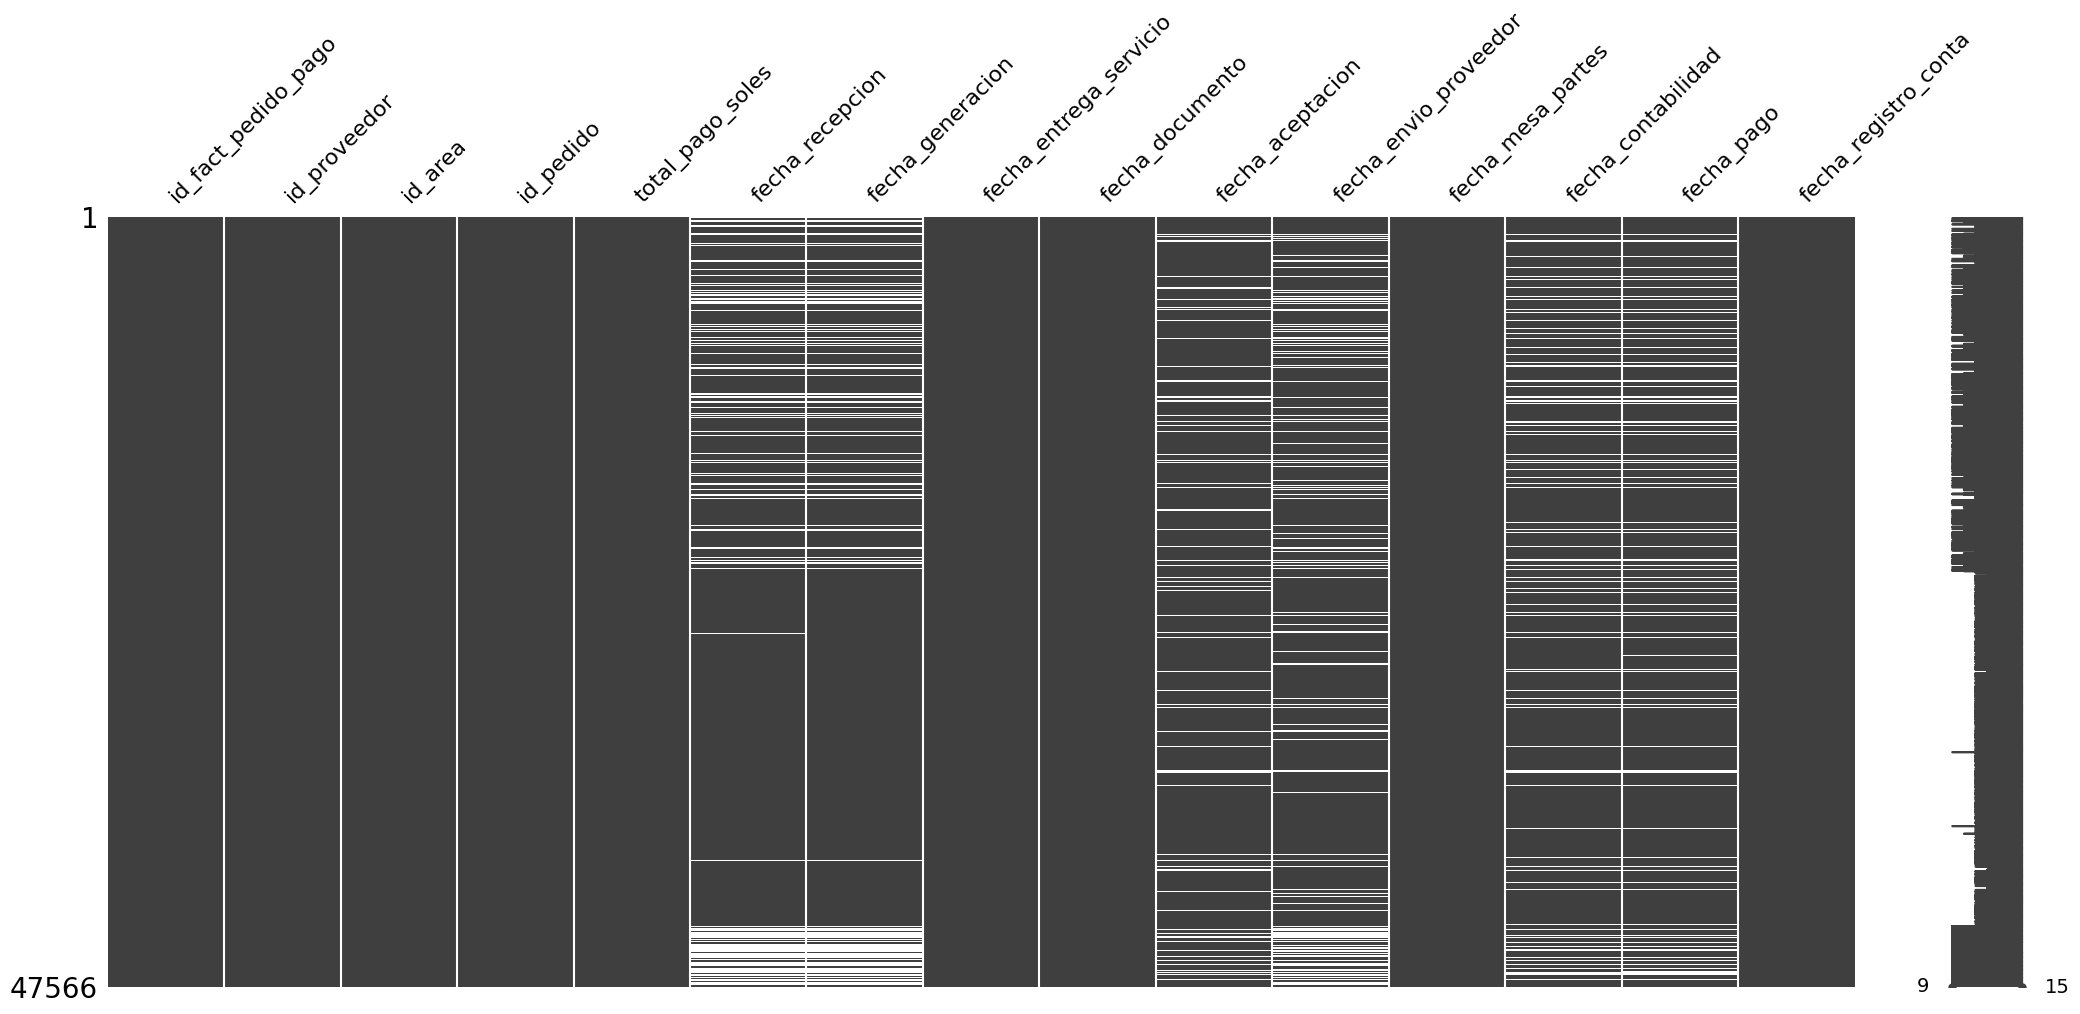

In [8]:
import missingno as msno
msno.matrix(fact_pagos)
plt.show()

In [9]:
# 🛠️ CONVERSIÓN DE FECHAS Y CÁLCULO DE LEAD TIME
print("🛠️ PROCESANDO FECHAS Y CALCULANDO LEAD TIME")
print("=" * 50)

# Convertir columnas de fecha
fecha_cols = ['fecha_recepcion', 'fecha_generacion', 'fecha_entrega_servicio', 
              'fecha_documento', 'fecha_aceptacion', 'fecha_envio_proveedor', 
              'fecha_mesa_partes', 'fecha_contabilidad', 'fecha_pago']

for col in fecha_cols:
    if col in fact_pagos.columns:
        # Convertir a datetime y manejar fechas inválidas
        fact_pagos[col] = pd.to_datetime(fact_pagos[col], errors='coerce', utc=True)
        
        # Convertir a timezone naive (sin zona horaria) para evitar conflictos
        fact_pagos[col] = fact_pagos[col].dt.tz_localize(None)
        
        # Manejar fechas inválidas como 1900-01-01
        #mask_invalid = fact_pagos[col].dt.year == 1900
        #fact_pagos.loc[mask_invalid, col] = pd.NaT

print("✅ Fechas convertidas a formato naive (sin zona horaria)")

# Verificar tipos de datos de fechas críticas
print(f"📅 Tipo de fecha_recepcion: {fact_pagos['fecha_recepcion'].dtype}")
print(f"📅 Tipo de fecha_pago: {fact_pagos['fecha_pago'].dtype}")

# Calcular Lead Time (días entre fecha_recepcion y fecha_pago)
print("🔢 Calculando Lead Time...")
fact_pagos['lead_time_dias'] = (fact_pagos['fecha_pago'] - fact_pagos['fecha_generacion']).dt.days

print(f"📊 Lead Time calculado para {fact_pagos['lead_time_dias'].notna().sum()} registros")
print(f"📊 Registros con fechas faltantes: {fact_pagos['lead_time_dias'].isna().sum()}")

# Estadísticas del Lead Time
print("\n📈 ESTADÍSTICAS DE LEAD TIME:")
valid_lead_times = fact_pagos['lead_time_dias'].dropna()
if len(valid_lead_times) > 0:
    print(valid_lead_times.describe())
    print(f"\n📊 Rango de Lead Time: {valid_lead_times.min()} a {valid_lead_times.max()} días")
else:
    print("⚠️ No hay Lead Times válidos calculados")


🛠️ PROCESANDO FECHAS Y CALCULANDO LEAD TIME
✅ Fechas convertidas a formato naive (sin zona horaria)
📅 Tipo de fecha_recepcion: datetime64[ns]
📅 Tipo de fecha_pago: datetime64[ns]
🔢 Calculando Lead Time...
📊 Lead Time calculado para 36650 registros
📊 Registros con fechas faltantes: 10916

📈 ESTADÍSTICAS DE LEAD TIME:
count    36650.000000
mean        28.493151
std         32.753341
min         -2.000000
25%         14.000000
50%         20.000000
75%         29.000000
max        458.000000
Name: lead_time_dias, dtype: float64

📊 Rango de Lead Time: -2.0 a 458.0 días


In [10]:
# 🔍 IDENTIFICAR REGISTRO CON LEAD TIME MÍNIMO (-2 días)
print("🔍 BUSCANDO REGISTRO CON LEAD TIME NEGATIVO MÍNIMO")
print("=" * 55)

# Calcular lead_time_dias como lo especificas
fact_pagos['lead_time_dias'] = (fact_pagos['fecha_pago'] - fact_pagos['fecha_generacion']).dt.days

# Verificar el valor mínimo
lead_time_min = fact_pagos['lead_time_dias'].min()
print(f"📊 Valor mínimo de Lead Time: {lead_time_min} días")

# Identificar el/los registros con el valor mínimo
registro_minimo = fact_pagos[fact_pagos['lead_time_dias'] == lead_time_min].copy()

print(f"\n🎯 REGISTRO(S) CON LEAD TIME DE {lead_time_min} DÍAS:")
print(f"📊 Cantidad de registros con este valor: {len(registro_minimo)}")

# Mostrar información completa del registro problemático
if len(registro_minimo) > 0:
    print(f"\n📋 DETALLES DEL REGISTRO PROBLEMÁTICO:")
    
    for idx, row in registro_minimo.iterrows():
        print(f"\n🔹 REGISTRO #{idx}:")
        print(f"   • ID Fact Pedido Pago: {row['id_fact_pedido_pago']}")
        print(f"   • ID Proveedor: {row['id_proveedor']}")
        print(f"   • ID Área: {row['id_area']}")
        print(f"   • ID Pedido: {row['id_pedido']}")
        print(f"   • Total Pago Soles: S/ {row['total_pago_soles']:,.2f}")
        print(f"   • Fecha Generación: {row['fecha_generacion']}")
        print(f"   • Fecha Pago: {row['fecha_pago']}")
        print(f"   • Lead Time: {row['lead_time_dias']} días")
        
        # Verificar otras fechas relevantes si existen
        fechas_adicionales = ['fecha_recepcion', 'fecha_documento', 'fecha_contabilidad', 
                             'fecha_entrega_servicio', 'fecha_aceptacion']
        
        print(f"   📅 OTRAS FECHAS RELEVANTES:")
        for fecha_col in fechas_adicionales:
            if fecha_col in fact_pagos.columns:
                fecha_valor = row[fecha_col]
                if pd.notna(fecha_valor):
                    print(f"      • {fecha_col}: {fecha_valor}")
                else:
                    print(f"      • {fecha_col}: NULL/NaN")

# Mostrar también todos los registros con Lead Time negativo
print(f"\n🚨 ANÁLISIS DE TODOS LOS LEAD TIMES NEGATIVOS:")
registros_negativos = fact_pagos[fact_pagos['lead_time_dias'] < 0].copy()

if len(registros_negativos) > 0:
    print(f"📊 Total de registros con Lead Time negativo: {len(registros_negativos)}")
    print(f"📊 Rango de Lead Times negativos: {registros_negativos['lead_time_dias'].min()} a {registros_negativos['lead_time_dias'].max()} días")
    
    # Mostrar estadísticas de los registros negativos
    print(f"\n📈 DISTRIBUCIÓN DE LEAD TIMES NEGATIVOS:")
    negativos_stats = registros_negativos['lead_time_dias'].value_counts().sort_index()
    print(negativos_stats)
    
    # Mostrar los 5 peores casos
    print(f"\n🔴 TOP 5 CASOS MÁS NEGATIVOS:")
    peores_casos = registros_negativos.nsmallest(5, 'lead_time_dias')[
        ['id_fact_pedido_pago', 'fecha_generacion', 'fecha_pago', 'lead_time_dias', 'total_pago_soles']
    ]
    print(peores_casos.to_string(index=False))
    
else:
    print("✅ No hay registros con Lead Time negativo")

# Verificar posibles causas
print(f"\n🔍 POSIBLES CAUSAS DE LEAD TIMES NEGATIVOS:")
print(f"   1. 📅 Errores en captura de fechas")
print(f"   2. ⚠️ Fechas ingresadas en orden incorrecto")
print(f"   3. 🔄 Procesos realizados fuera de secuencia normal")
print(f"   4. 💾 Problemas en la base de datos")

print(f"\n✅ Análisis completo del registro con Lead Time mínimo")

🔍 BUSCANDO REGISTRO CON LEAD TIME NEGATIVO MÍNIMO
📊 Valor mínimo de Lead Time: -2.0 días

🎯 REGISTRO(S) CON LEAD TIME DE -2.0 DÍAS:
📊 Cantidad de registros con este valor: 1

📋 DETALLES DEL REGISTRO PROBLEMÁTICO:

🔹 REGISTRO #23959:
   • ID Fact Pedido Pago: 23959
   • ID Proveedor: 1377
   • ID Área: 110
   • ID Pedido: 35240
   • Total Pago Soles: S/ 26,317.50
   • Fecha Generación: 2024-07-02 00:00:00
   • Fecha Pago: 2024-06-30 00:00:00
   • Lead Time: -2.0 días
   📅 OTRAS FECHAS RELEVANTES:
      • fecha_recepcion: 2024-07-02 00:00:00
      • fecha_documento: 2024-07-02 00:00:00
      • fecha_contabilidad: 2024-07-05 00:00:00
      • fecha_entrega_servicio: 2024-07-02 00:00:00
      • fecha_aceptacion: 2024-07-04 00:00:00

🚨 ANÁLISIS DE TODOS LOS LEAD TIMES NEGATIVOS:
📊 Total de registros con Lead Time negativo: 1
📊 Rango de Lead Times negativos: -2.0 a -2.0 días

📈 DISTRIBUCIÓN DE LEAD TIMES NEGATIVOS:
lead_time_dias
-2.0    1
Name: count, dtype: int64

🔴 TOP 5 CASOS MÁS NEGATIVO

In [11]:
# 🗑️ ELIMINACIÓN RÁPIDA DEL REGISTRO ID 23959
print("🗑️ ELIMINACIÓN RÁPIDA - ID 23959")

# Antes
registros_antes = len(fact_pagos)
lead_min_antes = fact_pagos['lead_time_dias'].min()

# Eliminar
fact_pagos = fact_pagos[fact_pagos['id_fact_pedido_pago'] != 23959].copy()

# Recalcular Lead Time
fact_pagos['lead_time_dias'] = (fact_pagos['fecha_pago'] - fact_pagos['fecha_generacion']).dt.days

# Después
registros_despues = len(fact_pagos)
lead_min_despues = fact_pagos['lead_time_dias'].min()

print(f"✅ Eliminado: {registros_antes - registros_despues} registro(s)")
print(f"📊 Lead Time mínimo: {lead_min_antes} → {lead_min_despues} días")
print(f"📊 Total registros: {registros_antes:,} → {registros_despues:,}")

🗑️ ELIMINACIÓN RÁPIDA - ID 23959
✅ Eliminado: 1 registro(s)
📊 Lead Time mínimo: -2.0 → 0.0 días
📊 Total registros: 47,566 → 47,565


In [12]:
# 🎯 IMPLEMENTACIÓN OPCIÓN 2: DATAFRAME SOLO CON IDs (SIN JOINS)
print("🎯 PREPROCESAMIENTO - OPCIÓN 2: SOLO IDs")
print("=" * 50)

# Empezar desde fact_pagos limpio (sin el registro problemático ya eliminado)
print("1️⃣ Preparando tabla principal (fact_pagos)...")
df_base = fact_pagos.copy()

# Verificar que tenemos el lead_time_dias calculado
if 'lead_time_dias' not in df_base.columns:
    df_base['lead_time_dias'] = (df_base['fecha_pago'] - df_base['fecha_generacion']).dt.days
    print("   ✅ Lead time recalculado")

print(f"   📊 Registros en fact_pagos: {len(df_base):,}")

# 🎯 SELECCIONAR SOLO COLUMNAS ESENCIALES CON IDs (SIN JOINS)
print("\n2️⃣ Seleccionando columnas esenciales con IDs...")

# Columnas esenciales para ML - SOLO IDs + variables numéricas + fechas + objetivo
columnas_esenciales_ids = [
    'id_fact_pedido_pago',    # ID principal (para referencia)
    'id_proveedor',           # ← Variable categórica (ID proveedor) - SIN nombre
    'id_area',                # ← Variable categórica (ID área) - SIN nombre
    'id_pedido',              # ← Variable categórica (ID pedido) - SIN estado
    'total_pago_soles',       # Variable numérica (monto)
    'fecha_generacion',       # Para features temporales
    'fecha_pago',             # Para features temporales
    'lead_time_dias'          # Variable objetivo
]

# Verificar que todas las columnas existen
columnas_disponibles = [col for col in columnas_esenciales_ids if col in df_base.columns]
columnas_faltantes = [col for col in columnas_esenciales_ids if col not in df_base.columns]

print(f"   ✅ Columnas disponibles: {len(columnas_disponibles)}")
if columnas_faltantes:
    print(f"   ❌ Columnas faltantes: {columnas_faltantes}")

# Crear DataFrame final SIN JOINS - solo con IDs
df_clean = df_base[columnas_disponibles].copy()

print(f"\n✅ DATAFRAME FINAL (OPCIÓN 2 - SOLO IDs):")
print(f"   📊 Total de registros: {len(df_clean):,}")
print(f"   📊 Total de columnas: {len(df_clean.columns)}")
print(f"   🚀 Sin joins innecesarios - Máxima eficiencia")

# Mostrar estructura del DataFrame
print(f"\n📋 ESTRUCTURA DEL DATAFRAME (SOLO IDs):")
for i, col in enumerate(df_clean.columns, 1):
    dtype = str(df_clean[col].dtype)
    nunique = df_clean[col].nunique()
    nulos = df_clean[col].isnull().sum()
    
    if 'id_' in col and col != 'id_fact_pedido_pago':
        categoria = "🔗 ID Categórico"
    elif col == 'id_fact_pedido_pago':
        categoria = "🆔 ID Principal"
    elif col in ['total_pago_soles', 'lead_time_dias']:
        categoria = "📊 Numérico"
    elif 'fecha' in col:
        categoria = "📅 Fecha"
    else:
        categoria = "❓ Otro"
        
    print(f"{i:2}. {col:<20} | {categoria:<15} | Únicos: {nunique:>6} | Nulos: {nulos:>5} | {dtype}")

# Estadísticas de las variables categóricas (IDs)
print(f"\n📊 ESTADÍSTICAS DE VARIABLES CATEGÓRICAS (IDs):")
variables_categoricas_ids = ['id_proveedor', 'id_area', 'id_pedido']

for col in variables_categoricas_ids:
    if col in df_clean.columns:
        nunique = df_clean[col].nunique()
        print(f"   🔗 {col}: {nunique:,} valores únicos")

print(f"\n🎉 PREPROCESAMIENTO OPCIÓN 2 COMPLETADO")
print(f"   ✅ DataFrame compacto con solo IDs")
print(f"   ✅ Sin tablas dimensionales innecesarias")
print(f"   ✅ Listo para crear características temporales")
print(f"   ✅ Perfecto para Machine Learning eficiente")

🎯 PREPROCESAMIENTO - OPCIÓN 2: SOLO IDs
1️⃣ Preparando tabla principal (fact_pagos)...
   📊 Registros en fact_pagos: 47,565

2️⃣ Seleccionando columnas esenciales con IDs...
   ✅ Columnas disponibles: 8

✅ DATAFRAME FINAL (OPCIÓN 2 - SOLO IDs):
   📊 Total de registros: 47,565
   📊 Total de columnas: 8
   🚀 Sin joins innecesarios - Máxima eficiencia

📋 ESTRUCTURA DEL DATAFRAME (SOLO IDs):
 1. id_fact_pedido_pago  | 🆔 ID Principal  | Únicos:  47565 | Nulos:     0 | int64
 2. id_proveedor         | 🔗 ID Categórico | Únicos:   3932 | Nulos:     0 | int64
 3. id_area              | 🔗 ID Categórico | Únicos:    349 | Nulos:     0 | int64
 4. id_pedido            | 🔗 ID Categórico | Únicos:  47565 | Nulos:     0 | int64
 5. total_pago_soles     | 📊 Numérico      | Únicos:  31060 | Nulos:     4 | float64
 6. fecha_generacion     | 📅 Fecha         | Únicos:    362 | Nulos:  6200 | datetime64[ns]
 7. fecha_pago           | 📅 Fecha         | Únicos:    606 | Nulos:  6271 | datetime64[ns]
 8. lead

## 4️⃣ ANÁLISIS EXPLORATORIO DE DATOS

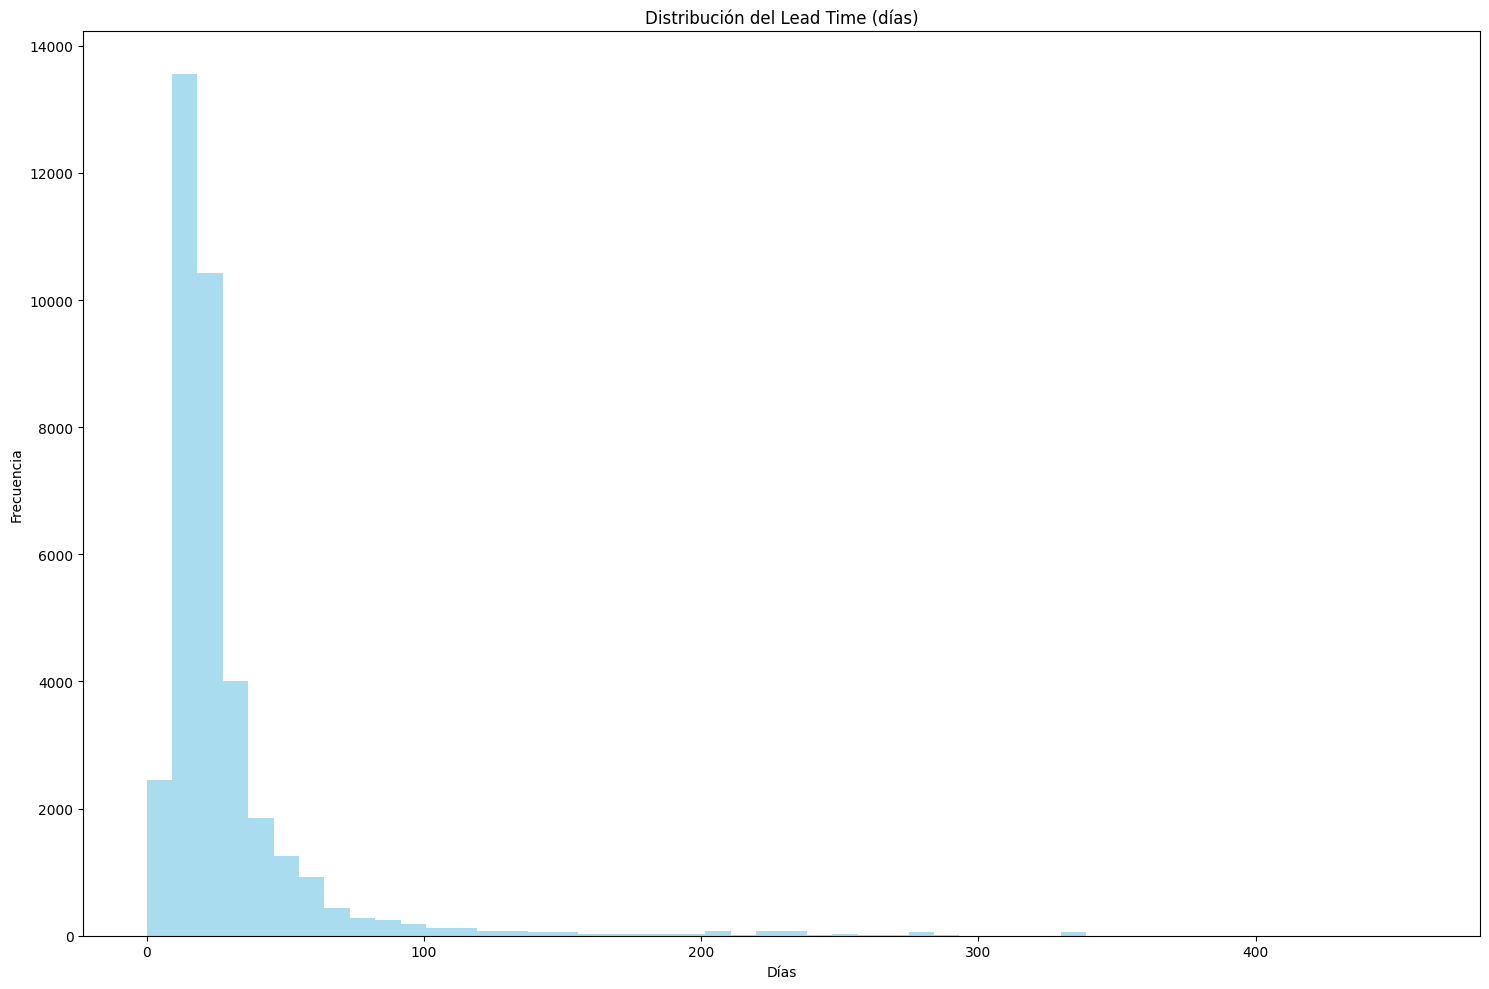

📊 Visualizaciones generadas


In [13]:

fig, ax = plt.subplots(figsize=(15, 10))  # Solo un eje, no hace falta (1,1)

# Histograma del Lead Time
ax.hist(df_clean['lead_time_dias'], bins=50, alpha=0.7, color='skyblue')
ax.set_title('Distribución del Lead Time (días)')
ax.set_xlabel('Días')
ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("📊 Visualizaciones generadas")


In [14]:
# 🚀 CREACIÓN DE CARACTERÍSTICAS TEMPORALES (OPCIÓN 2)
print("🚀 CREANDO CARACTERÍSTICAS TEMPORALES DESDE FECHAS")
print("=" * 55)



print(f"\n✅ DATAFRAME FINAL PARA ML (OPCIÓN 2):")
print(f"   📊 Registros: {len(df_clean):,}")
print(f"   📊 Columnas: {len(df_clean.columns)}")

# Mostrar estructura final
print(f"\n📋 ESTRUCTURA FINAL:")
for i, col in enumerate(df_clean.columns, 1):
    dtype = str(df_clean[col].dtype)
    nunique = df_clean[col].nunique()
    nulos = df_clean[col].isnull().sum()
    
    if 'id_' in col and col != 'id_fact_pedido_pago':
        categoria = "🔗 ID Categórico"
    elif col == 'id_fact_pedido_pago':
        categoria = "🆔 ID Principal"
    elif col in ['total_pago_soles', 'lead_time_dias']:
        categoria = "📊 Numérico"
    elif col.startswith('pago_'):
        categoria = "📅 Temporal"
    else:
        categoria = "❓ Otro"
        
    print(f"{i:2}. {col:<20} | {categoria:<15} | Únicos: {nunique:>6} | Nulos: {nulos:>5}")

print(f"\n🎉 CARACTERÍSTICAS LISTAS PARA MACHINE LEARNING")
print(f"   ✅ Variables categóricas: id_proveedor, id_area, id_pedido")
print(f"   ✅ Variables numéricas: total_pago_soles + 5 temporales")
print(f"   ✅ Variable objetivo: lead_time_dias")

🚀 CREANDO CARACTERÍSTICAS TEMPORALES DESDE FECHAS

✅ DATAFRAME FINAL PARA ML (OPCIÓN 2):
   📊 Registros: 47,565
   📊 Columnas: 8

📋 ESTRUCTURA FINAL:
 1. id_fact_pedido_pago  | 🆔 ID Principal  | Únicos:  47565 | Nulos:     0
 2. id_proveedor         | 🔗 ID Categórico | Únicos:   3932 | Nulos:     0
 3. id_area              | 🔗 ID Categórico | Únicos:    349 | Nulos:     0
 4. id_pedido            | 🔗 ID Categórico | Únicos:  47565 | Nulos:     0
 5. total_pago_soles     | 📊 Numérico      | Únicos:  31060 | Nulos:     4
 6. fecha_generacion     | ❓ Otro          | Únicos:    362 | Nulos:  6200
 7. fecha_pago           | ❓ Otro          | Únicos:    606 | Nulos:  6271
 8. lead_time_dias       | 📊 Numérico      | Únicos:    272 | Nulos: 10916

🎉 CARACTERÍSTICAS LISTAS PARA MACHINE LEARNING
   ✅ Variables categóricas: id_proveedor, id_area, id_pedido
   ✅ Variables numéricas: total_pago_soles + 5 temporales
   ✅ Variable objetivo: lead_time_dias


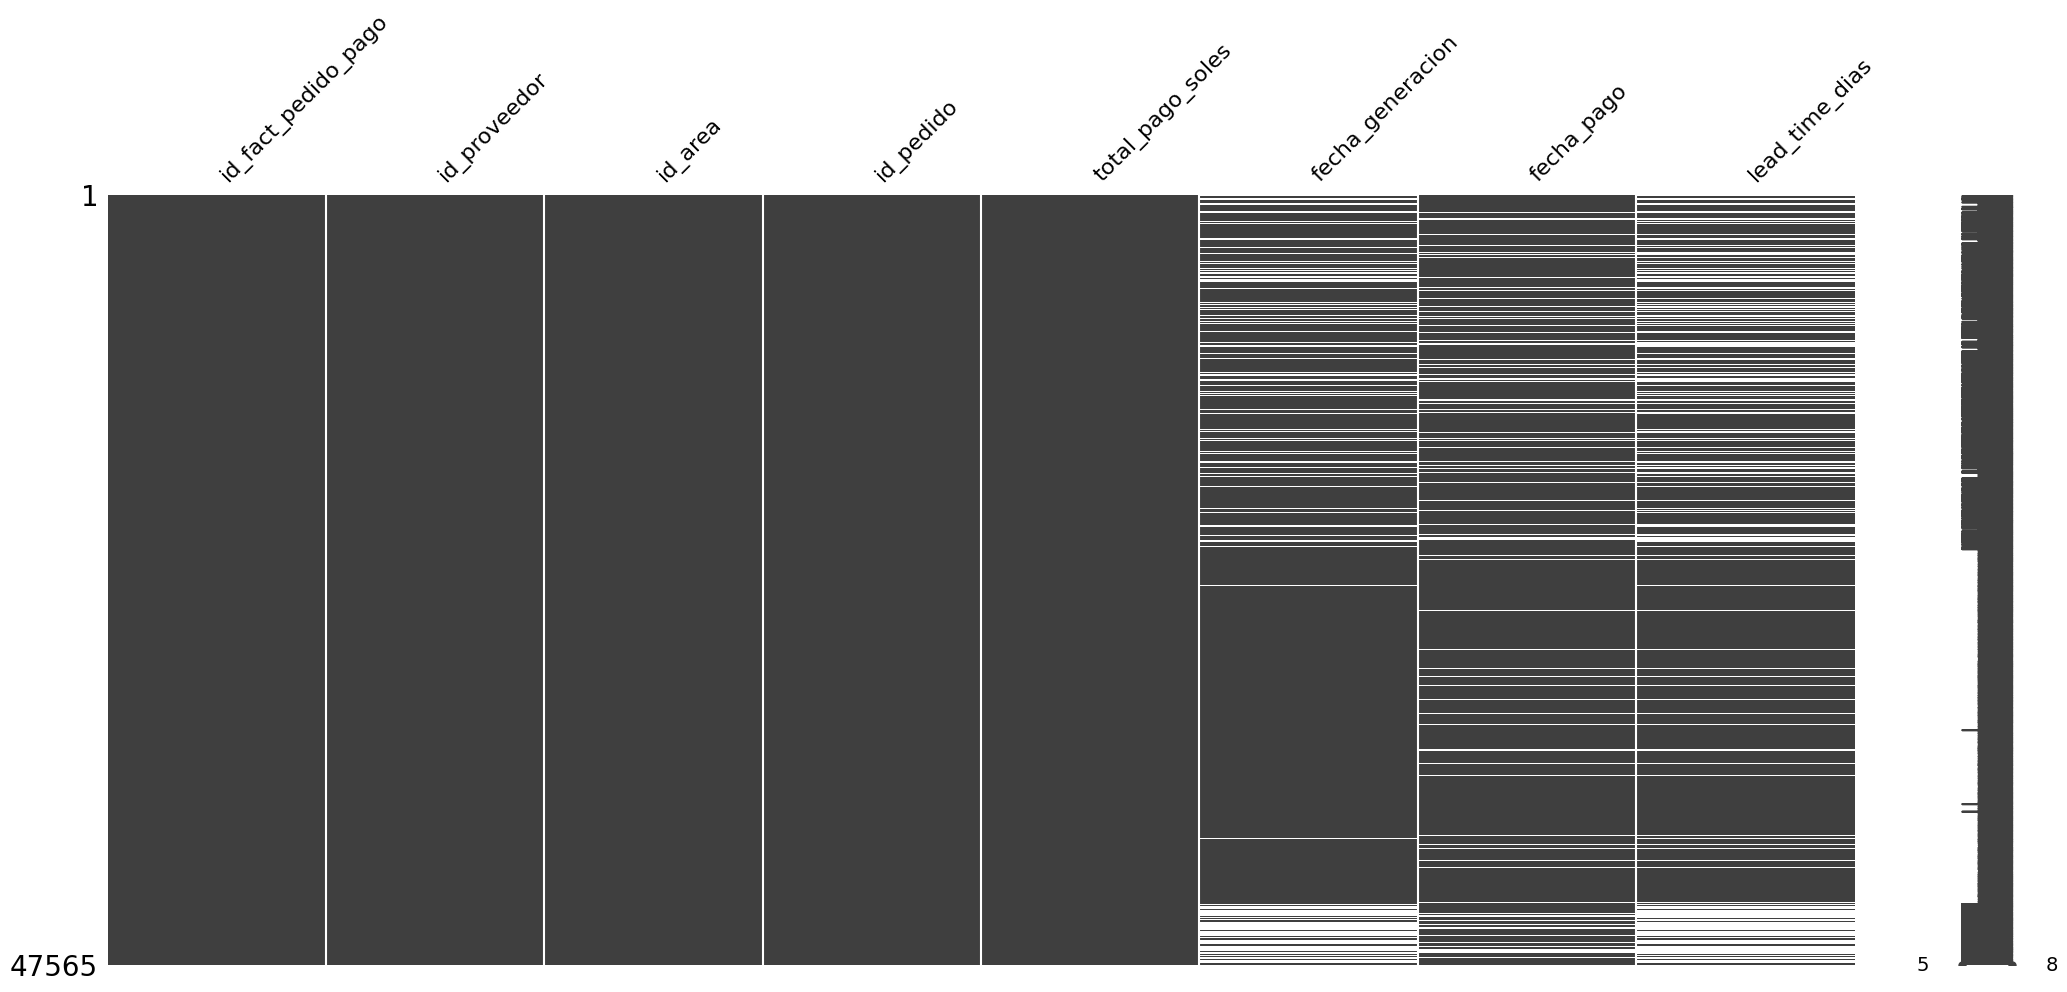

In [15]:
msno.matrix(df_clean)
plt.show()

In [16]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47565 entries, 0 to 47565
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id_fact_pedido_pago  47565 non-null  int64         
 1   id_proveedor         47565 non-null  int64         
 2   id_area              47565 non-null  int64         
 3   id_pedido            47565 non-null  int64         
 4   total_pago_soles     47561 non-null  float64       
 5   fecha_generacion     41365 non-null  datetime64[ns]
 6   fecha_pago           41294 non-null  datetime64[ns]
 7   lead_time_dias       36649 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(4)
memory usage: 3.3 MB


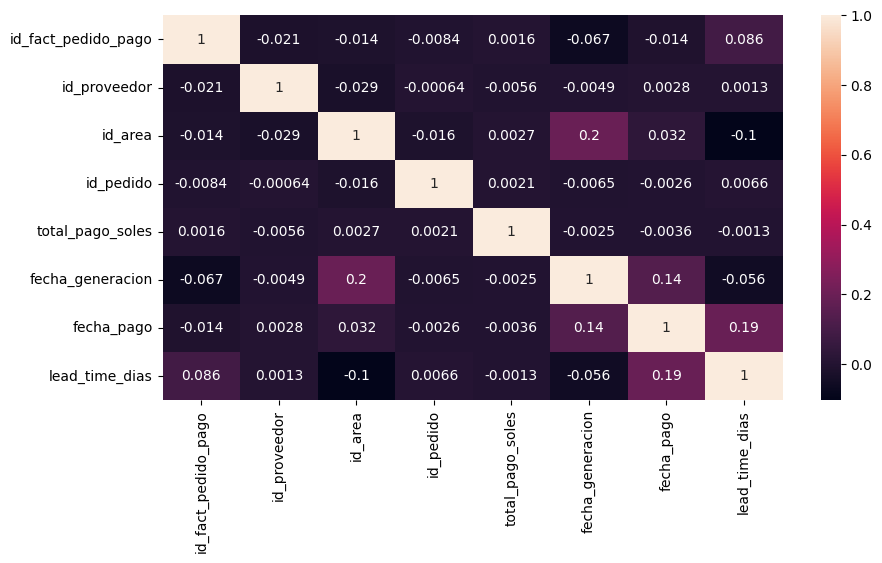

In [17]:
plt.figure(figsize=(10,5))
sns.heatmap(df_clean.corr(), annot = True)
plt.show()

In [18]:
# 🛠️ FUNCIÓN DE IMPUTACIÓN CORREGIDA
def imputar_valores_faltantes_corregida(df):
    """
    Imputa valores faltantes de forma segura, excluyendo columnas de fechas
    """
    print("🔧 INICIANDO IMPUTACIÓN SEGURA DE VALORES FALTANTES")
    print("=" * 55)
    
    df_imputado = df.copy()
    
    # 1️⃣ IDENTIFICAR TIPOS DE COLUMNAS
    print("🔍 Analizando tipos de columnas...")
    
    # Columnas de fechas (excluir del KNN)
    columnas_fechas = []
    for col in df.columns:
        if 'fecha' in col.lower() or df[col].dtype == 'datetime64[ns]':
            columnas_fechas.append(col)
    
    # Columnas numéricas (para KNN)
    columnas_numericas = []
    for col in df.columns:
        if col not in columnas_fechas and pd.api.types.is_numeric_dtype(df[col]):
            columnas_numericas.append(col)
    
    # Columnas categóricas (para moda)
    columnas_categoricas = []
    for col in df.columns:
        if col not in columnas_fechas and col not in columnas_numericas:
            columnas_categoricas.append(col)
    
    print(f"   📅 Columnas de fechas ({len(columnas_fechas)}): {columnas_fechas[:3]}...")
    print(f"   🔢 Columnas numéricas ({len(columnas_numericas)}): {columnas_numericas[:3]}...")
    print(f"   📝 Columnas categóricas ({len(columnas_categoricas)}): {columnas_categoricas[:3]}...")
    
    # 2️⃣ IMPUTAR FECHAS (usando forward fill + backward fill)
    if columnas_fechas:
        print(f"\n📅 Imputando {len(columnas_fechas)} columnas de fechas...")
        for col in columnas_fechas:
            valores_faltantes_antes = df_imputado[col].isnull().sum()
            if valores_faltantes_antes > 0:
                # Método 1: Forward fill + Backward fill
                df_imputado[col] = df_imputado[col].fillna(method='ffill').fillna(method='bfill')
                
                # Si aún hay valores faltantes, usar una fecha de referencia
                if df_imputado[col].isnull().sum() > 0:
                    fecha_referencia = df_imputado[col].dropna().iloc[0] if len(df_imputado[col].dropna()) > 0 else pd.Timestamp('2023-01-01')
                    df_imputado[col] = df_imputado[col].fillna(fecha_referencia)
                
                valores_faltantes_despues = df_imputado[col].isnull().sum()
                print(f"   ✅ {col}: {valores_faltantes_antes} → {valores_faltantes_despues} valores faltantes")
    
    # 3️⃣ IMPUTAR COLUMNAS NUMÉRICAS CON KNN
    if columnas_numericas:
        print(f"\n🔢 Imputando {len(columnas_numericas)} columnas numéricas con KNN...")
        
        # Verificar que no hay valores infinitos o NaT en columnas numéricas
        datos_numericos = df_imputado[columnas_numericas].copy()
        
        # Limpiar valores problemáticos
        datos_numericos = datos_numericos.replace([np.inf, -np.inf], np.nan)
        
        # Verificar que todas las columnas son realmente numéricas
        columnas_numericas_validas = []
        for col in columnas_numericas:
            try:
                pd.to_numeric(datos_numericos[col], errors='coerce')
                columnas_numericas_validas.append(col)
            except:
                print(f"   ⚠️ Excluyendo {col} - no es numérica válida")
        
        if columnas_numericas_validas:
            datos_para_knn = datos_numericos[columnas_numericas_validas]
            
            # Aplicar KNN solo si hay datos para procesar
            if not datos_para_knn.empty and datos_para_knn.isnull().sum().sum() > 0:
                knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
                
                print("   🔄 Aplicando KNN Imputer a columnas numéricas...")
                try:
                    datos_imputados = knn_imputer.fit_transform(datos_para_knn)
                    
                    # Actualizar DataFrame
                    df_knn_result = pd.DataFrame(
                        datos_imputados, 
                        columns=columnas_numericas_validas, 
                        index=df_imputado.index
                    )
                    
                    for col in columnas_numericas_validas:
                        valores_faltantes_antes = df_imputado[col].isnull().sum()
                        df_imputado[col] = df_knn_result[col]
                        valores_faltantes_despues = df_imputado[col].isnull().sum()
                        print(f"   ✅ {col}: {valores_faltantes_antes} → {valores_faltantes_despues} valores faltantes")
                        
                except Exception as e:
                    print(f"   ❌ Error en KNN: {e}")
                    print("   🔄 Usando imputación simple como respaldo...")
                    
                    # Respaldo: usar mediana para numéricas
                    for col in columnas_numericas_validas:
                        if df_imputado[col].isnull().sum() > 0:
                            mediana = df_imputado[col].median()
                            df_imputado[col] = df_imputado[col].fillna(mediana)
                            print(f"   ✅ {col}: imputado con mediana = {mediana:.2f}")
    
    # 4️⃣ IMPUTAR COLUMNAS CATEGÓRICAS
    if columnas_categoricas:
        print(f"\n📝 Imputando {len(columnas_categoricas)} columnas categóricas...")
        for col in columnas_categoricas:
            valores_faltantes_antes = df_imputado[col].isnull().sum()
            if valores_faltantes_antes > 0:
                moda = df_imputado[col].mode()
                valor_moda = moda[0] if len(moda) > 0 else 'DESCONOCIDO'
                df_imputado[col] = df_imputado[col].fillna(valor_moda)
                valores_faltantes_despues = df_imputado[col].isnull().sum()
                print(f"   ✅ {col}: {valores_faltantes_antes} → {valores_faltantes_despues} (moda: {valor_moda})")
    
    # 5️⃣ VERIFICACIÓN FINAL
    print(f"\n✅ IMPUTACIÓN COMPLETADA:")
    valores_faltantes_final = df_imputado.isnull().sum().sum()
    print(f"   📊 Valores faltantes restantes: {valores_faltantes_final}")
    
    if valores_faltantes_final == 0:
        print("   🎉 ¡Todos los valores faltantes fueron imputados exitosamente!")
    else:
        print("   ⚠️ Aún hay algunos valores faltantes")
        print("   Columnas con valores faltantes:")
        for col, count in df_imputado.isnull().sum().items():
            if count > 0:
                print(f"      • {col}: {count} valores")
    
    return df_imputado

# 🚀 APLICAR LA FUNCIÓN CORREGIDA
print("🚀 APLICANDO IMPUTACIÓN CORREGIDA AL DATASET")
print("=" * 50)

# Aplicar a tus datos
df_clean_imputado = imputar_valores_faltantes_corregida(df_clean)

# Verificar resultado
print(f"\n📊 RESULTADO FINAL:")
print(f"   • Forma original: {df_clean.shape}")
print(f"   • Forma final: {df_clean_imputado.shape}")
print(f"   • Valores faltantes eliminados: {df_clean.isnull().sum().sum() - df_clean_imputado.isnull().sum().sum()}")

🚀 APLICANDO IMPUTACIÓN CORREGIDA AL DATASET
🔧 INICIANDO IMPUTACIÓN SEGURA DE VALORES FALTANTES
🔍 Analizando tipos de columnas...
   📅 Columnas de fechas (2): ['fecha_generacion', 'fecha_pago']...
   🔢 Columnas numéricas (6): ['id_fact_pedido_pago', 'id_proveedor', 'id_area']...
   📝 Columnas categóricas (0): []...

📅 Imputando 2 columnas de fechas...
   ✅ fecha_generacion: 6200 → 0 valores faltantes
   ✅ fecha_pago: 6271 → 0 valores faltantes

🔢 Imputando 6 columnas numéricas con KNN...
   🔄 Aplicando KNN Imputer a columnas numéricas...
   ✅ id_fact_pedido_pago: 0 → 0 valores faltantes
   ✅ id_proveedor: 0 → 0 valores faltantes
   ✅ id_area: 0 → 0 valores faltantes
   ✅ id_pedido: 0 → 0 valores faltantes
   ✅ total_pago_soles: 4 → 0 valores faltantes
   ✅ lead_time_dias: 10916 → 0 valores faltantes

✅ IMPUTACIÓN COMPLETADA:
   📊 Valores faltantes restantes: 0
   🎉 ¡Todos los valores faltantes fueron imputados exitosamente!

📊 RESULTADO FINAL:
   • Forma original: (47565, 8)
   • Forma 

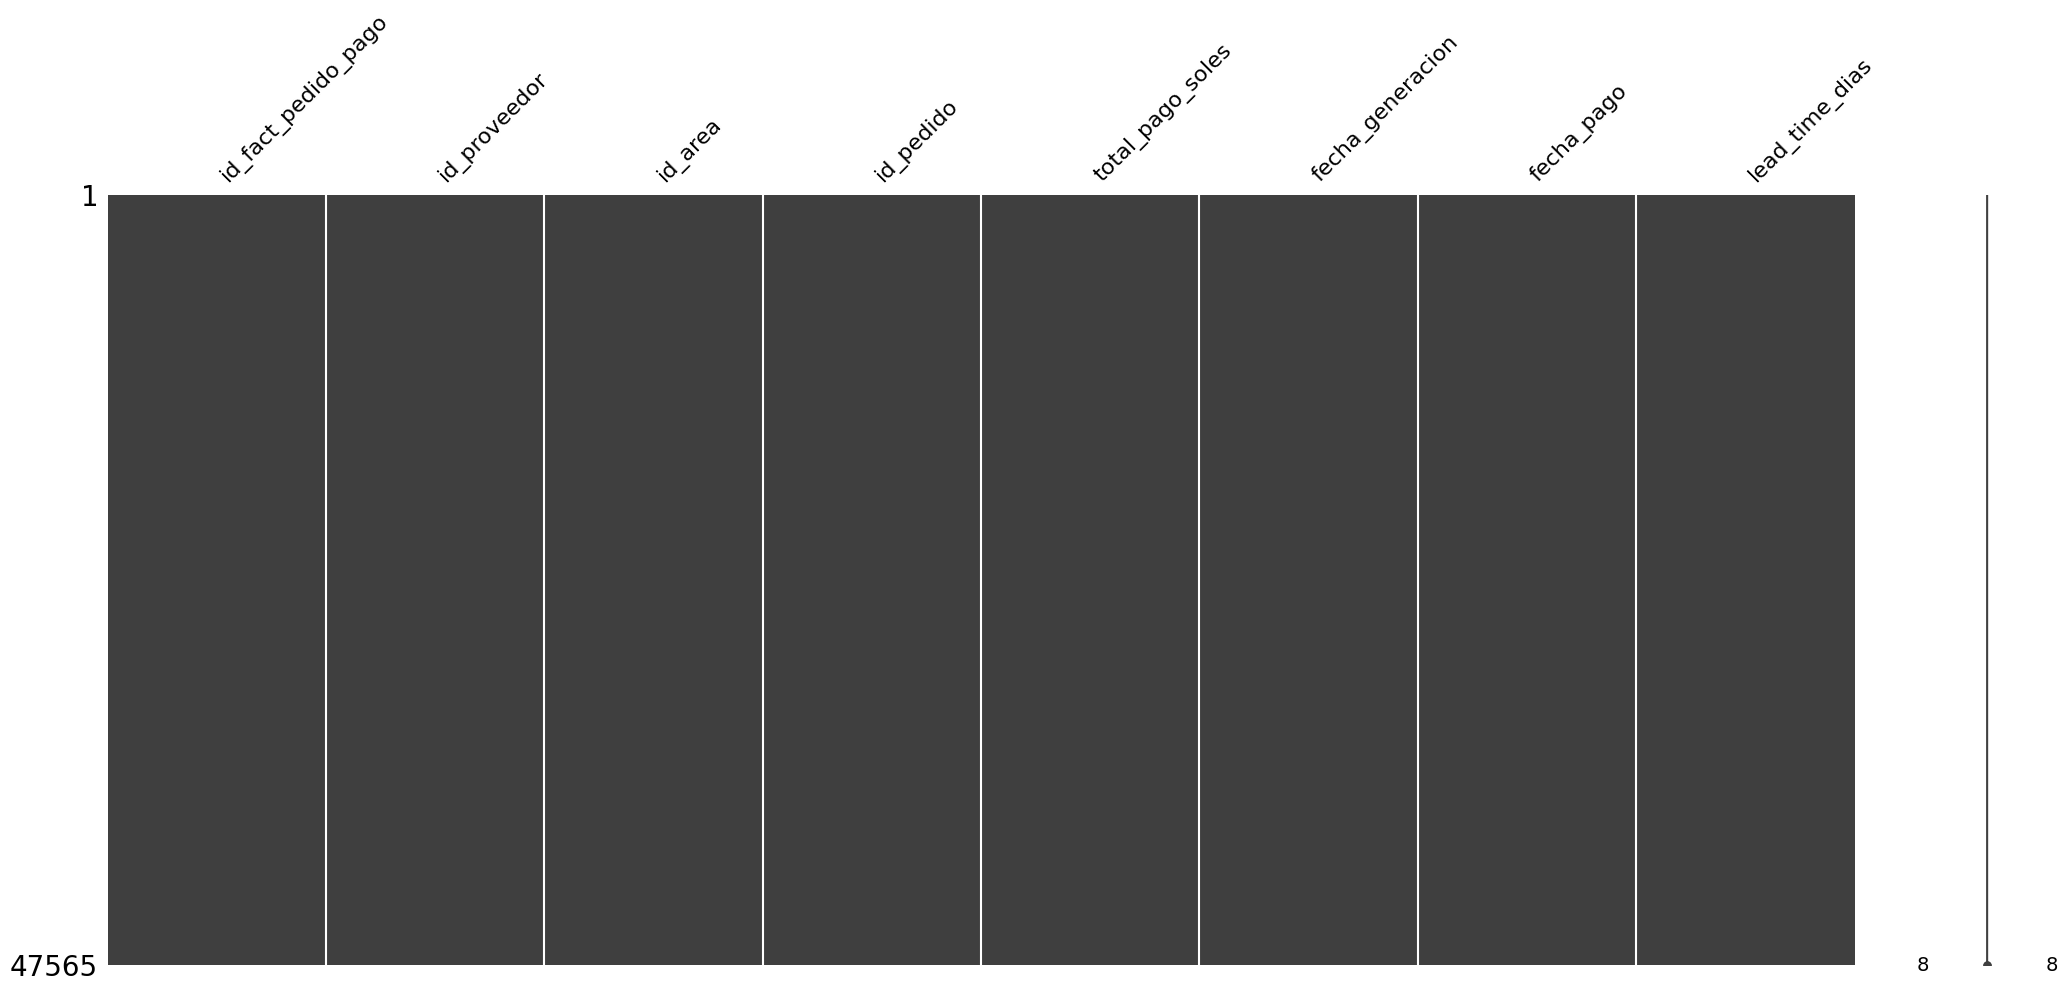

In [28]:
msno.matrix(df_clean_imputado)
plt.show()

## 5️⃣ PREPARACIÓN DE CARACTERÍSTICAS PARA ML

In [29]:
# 🎯 PREPARAR DATOS PARA MACHINE LEARNING
print("🎯 PREPARANDO DATOS PARA MACHINE LEARNING")
print("=" * 50)

# Examinar las columnas disponibles
print("📋 COLUMNAS DISPONIBLES:")
for i, col in enumerate(df_clean_imputado.columns, 1):
    dtype = str(df_clean_imputado[col].dtype)
    nunique = df_clean_imputado[col].nunique()
    print(f"{i:2}. {col:<25} | Tipo: {dtype:<15} | Únicos: {nunique:>6}")

print(f"\n📊 ESTADÍSTICAS DEL DATASET:")
print(f"   • Registros totales: {df_clean_imputado.shape[0]:,}")
print(f"   • Columnas: {df_clean_imputado.shape[1]}")
print(f"   • Valores faltantes: {df_clean_imputado.isnull().sum().sum()}")

# Verificar la variable objetivo
print(f"\n🎯 VARIABLE OBJETIVO - Lead Time:")
print(f"   • Media: {df_clean_imputado['lead_time_dias'].mean():.2f} días")
print(f"   • Mediana: {df_clean_imputado['lead_time_dias'].median():.2f} días")
print(f"   • Desv. Estándar: {df_clean_imputado['lead_time_dias'].std():.2f} días")
print(f"   • Mínimo: {df_clean_imputado['lead_time_dias'].min():.2f} días")
print(f"   • Máximo: {df_clean_imputado['lead_time_dias'].max():.2f} días")


🎯 PREPARANDO DATOS PARA MACHINE LEARNING
📋 COLUMNAS DISPONIBLES:
 1. id_fact_pedido_pago       | Tipo: float64         | Únicos:  47565
 2. id_proveedor              | Tipo: float64         | Únicos:   3932
 3. id_area                   | Tipo: float64         | Únicos:    349
 4. id_pedido                 | Tipo: float64         | Únicos:  47565
 5. total_pago_soles          | Tipo: float64         | Únicos:  31064
 6. fecha_generacion          | Tipo: datetime64[ns]  | Únicos:    362
 7. fecha_pago                | Tipo: datetime64[ns]  | Únicos:    606
 8. lead_time_dias            | Tipo: float64         | Únicos:  11188

📊 ESTADÍSTICAS DEL DATASET:
   • Registros totales: 47,565
   • Columnas: 8
   • Valores faltantes: 0

🎯 VARIABLE OBJETIVO - Lead Time:
   • Media: 31.14 días
   • Mediana: 21.00 días
   • Desv. Estándar: 34.19 días
   • Mínimo: 0.00 días
   • Máximo: 458.00 días


In [30]:
# 🔧 SEPARAR CARACTERÍSTICAS Y VARIABLE OBJETIVO
print("🔧 SEPARANDO CARACTERÍSTICAS Y VARIABLE OBJETIVO")
print("=" * 50)

# Identificar columnas para características (X)
# Excluir: variable objetivo, fechas, y columnas ID innecesarias
columnas_excluir = ['lead_time_dias', 'fecha_generacion', 'fecha_pago', 'id_fact_pedido_pago']

# Crear características (X)
X = df_clean_imputado.drop(columns=columnas_excluir)
y = df_clean_imputado['lead_time_dias']

print(f"📋 CARACTERÍSTICAS SELECCIONADAS (X):")
for i, col in enumerate(X.columns, 1):
    dtype = str(X[col].dtype)
    nunique = X[col].nunique()
    print(f"{i:2}. {col:<20} | Tipo: {dtype:<15} | Únicos: {nunique:>6}")

print(f"\n🎯 VARIABLE OBJETIVO (y):")
print(f"   • Nombre: lead_time_dias")
print(f"   • Tipo: {y.dtype}")
print(f"   • Forma: {y.shape}")

print(f"\n📊 RESUMEN:")
print(f"   • Características (X): {X.shape}")
print(f"   • Variable objetivo (y): {y.shape}")
print(f"   • Total de muestras: {len(X):,}")

# Verificar si hay valores infinitos o problemáticos
print(f"\n🔍 VERIFICACIÓN DE CALIDAD DE DATOS:")
for col in X.columns:
    infinitos = np.isinf(X[col]).sum()
    nulos = X[col].isnull().sum()
    if infinitos > 0 or nulos > 0:
        print(f"   ⚠️ {col}: {nulos} nulos, {infinitos} infinitos")

if y.isnull().sum() > 0:
    print(f"   ⚠️ Variable objetivo: {y.isnull().sum()} valores nulos")
else:
    print("   ✅ Todos los datos están limpios")


🔧 SEPARANDO CARACTERÍSTICAS Y VARIABLE OBJETIVO
📋 CARACTERÍSTICAS SELECCIONADAS (X):
 1. id_proveedor         | Tipo: float64         | Únicos:   3932
 2. id_area              | Tipo: float64         | Únicos:    349
 3. id_pedido            | Tipo: float64         | Únicos:  47565
 4. total_pago_soles     | Tipo: float64         | Únicos:  31064

🎯 VARIABLE OBJETIVO (y):
   • Nombre: lead_time_dias
   • Tipo: float64
   • Forma: (47565,)

📊 RESUMEN:
   • Características (X): (47565, 4)
   • Variable objetivo (y): (47565,)
   • Total de muestras: 47,565

🔍 VERIFICACIÓN DE CALIDAD DE DATOS:
   ✅ Todos los datos están limpios


In [31]:
# 📊 DIVISIÓN DE DATOS Y ESCALADO
print("📊 DIVISIÓN DE DATOS EN ENTRENAMIENTO Y PRUEBA")
print("=" * 50)

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"✅ DIVISIÓN COMPLETADA:")
print(f"   • Entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   • Prueba: {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"   • Características: {X_train.shape[1]}")

# Estadísticas de la variable objetivo en cada conjunto
print(f"\n📈 ESTADÍSTICAS DE LEAD TIME POR CONJUNTO:")
print(f"   ENTRENAMIENTO:")
print(f"   • Media: {y_train.mean():.2f} días")
print(f"   • Mediana: {y_train.median():.2f} días")
print(f"   • Desv. Est: {y_train.std():.2f} días")

print(f"   PRUEBA:")
print(f"   • Media: {y_test.mean():.2f} días")
print(f"   • Mediana: {y_test.median():.2f} días")
print(f"   • Desv. Est: {y_test.std():.2f} días")

# Preparar escalado para modelos que lo requieren
print(f"\n🔧 PREPARANDO ESCALADO DE CARACTERÍSTICAS:")
scaler = StandardScaler()

# Crear copias escaladas
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"   ✅ Escalado aplicado a {X_train.shape[1]} características")
print(f"   ✅ Datos listos para entrenamiento")


📊 DIVISIÓN DE DATOS EN ENTRENAMIENTO Y PRUEBA
✅ DIVISIÓN COMPLETADA:
   • Entrenamiento: 38,052 registros (80.0%)
   • Prueba: 9,513 registros (20.0%)
   • Características: 4

📈 ESTADÍSTICAS DE LEAD TIME POR CONJUNTO:
   ENTRENAMIENTO:
   • Media: 31.19 días
   • Mediana: 21.00 días
   • Desv. Est: 34.27 días
   PRUEBA:
   • Media: 30.94 días
   • Mediana: 21.00 días
   • Desv. Est: 33.83 días

🔧 PREPARANDO ESCALADO DE CARACTERÍSTICAS:
   ✅ Escalado aplicado a 4 características
   ✅ Datos listos para entrenamiento


## 6️⃣ ENTRENAMIENTO DE MODELOS DE MACHINE LEARNING

In [32]:
# 🤖 ENTRENAMIENTO DE MÚLTIPLES MODELOS DE REGRESIÓN
print("🤖 ENTRENAMIENTO DE MÚLTIPLES MODELOS DE REGRESIÓN")
print("=" * 55)

# Definir modelos a entrenar
modelos = {
    'Random Forest': RandomForestRegressor(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, 
        random_state=42
    ),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(
        random_state=42, 
        max_depth=10
    ),
    'SVR': SVR(kernel='rbf', C=1.0, gamma='scale')
}

# Diccionario para almacenar resultados
resultados_modelos = {}

print(f"🏋️ Entrenando {len(modelos)} modelos diferentes...")

# Entrenar cada modelo
for nombre_modelo, modelo in modelos.items():
    print(f"\n🔧 Entrenando {nombre_modelo}...")
    
    # Usar datos escalados para modelos lineales y SVM
    if nombre_modelo in ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'SVR']:
        # Entrenar con datos escalados
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)
    else:
        # Entrenar con datos originales
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
    
    # Calcular métricas de evaluación
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    # Calcular MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1))) * 100
    
    # Almacenar resultados
    resultados_modelos[nombre_modelo] = {
        'modelo': modelo,
        'predicciones': y_pred,
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE': mape
    }
    
    print(f"   ✅ {nombre_modelo} completado:")
    print(f"      • R²: {r2:.4f}")
    print(f"      • RMSE: {rmse:.2f} días")
    print(f"      • MAE: {mae:.2f} días")
    print(f"      • MAPE: {mape:.2f}%")

print(f"\n🎯 ¡Entrenamiento de {len(modelos)} modelos completado!")


🤖 ENTRENAMIENTO DE MÚLTIPLES MODELOS DE REGRESIÓN
🏋️ Entrenando 7 modelos diferentes...

🔧 Entrenando Random Forest...
   ✅ Random Forest completado:
      • R²: 0.2963
      • RMSE: 28.38 días
      • MAE: 15.88 días
      • MAPE: 66.72%

🔧 Entrenando Gradient Boosting...
   ✅ Gradient Boosting completado:
      • R²: 0.2666
      • RMSE: 28.97 días
      • MAE: 16.32 días
      • MAPE: 69.88%

🔧 Entrenando Linear Regression...
   ✅ Linear Regression completado:
      • R²: 0.0179
      • RMSE: 33.53 días
      • MAE: 18.67 días
      • MAPE: 80.89%

🔧 Entrenando Ridge Regression...
   ✅ Ridge Regression completado:
      • R²: 0.0179
      • RMSE: 33.53 días
      • MAE: 18.67 días
      • MAPE: 80.89%

🔧 Entrenando Lasso Regression...
   ✅ Lasso Regression completado:
      • R²: 0.0171
      • RMSE: 33.54 días
      • MAE: 18.60 días
      • MAPE: 80.74%

🔧 Entrenando Decision Tree...
   ✅ Decision Tree completado:
      • R²: 0.2328
      • RMSE: 29.63 días
      • MAE: 16.18 días

In [34]:
# 📊 COMPARACIÓN Y EVALUACIÓN DE MODELOS
print("📊 COMPARACIÓN Y EVALUACIÓN DE MODELOS")
print("=" * 45)

# Crear DataFrame con resultados para comparación
resultados_df = pd.DataFrame({
    nombre: {
        'R²': datos['R²'],
        'RMSE': datos['RMSE'],
        'MAE': datos['MAE'],
        'MAPE': datos['MAPE'],
        'MSE': datos['MSE']
    }
    for nombre, datos in resultados_modelos.items()
}).T

# Ordenar por R² descendente (mejor performance)
resultados_df = resultados_df.sort_values('R²', ascending=False)

print("🏆 RANKING DE MODELOS (ordenado por R²):")
print("=" * 80)
print(f"{'Modelo':<18} {'R²':<8} {'RMSE':<8} {'MAE':<8} {'MAPE':<8}")
print("-" * 80)

for i, (modelo, row) in enumerate(resultados_df.iterrows(), 1):
    print(f"{i}. {modelo:<15} {row['R²']:>6.4f} {row['RMSE']:>7.2f} {row['MAE']:>7.2f} {row['MAPE']:>7.2f}%")

# Identificar el mejor modelo
mejor_modelo_nombre = resultados_df.index[0]
mejor_modelo_datos = resultados_modelos[mejor_modelo_nombre]

print(f"\n🥇 MEJOR MODELO: {mejor_modelo_nombre}")
print("=" * 40)
print(f"   • R² Score: {mejor_modelo_datos['R²']:.4f} ({mejor_modelo_datos['R²']*100:.2f}% de varianza explicada)")
print(f"   • RMSE: {mejor_modelo_datos['RMSE']:.2f} días")
print(f"   • MAE: {mejor_modelo_datos['MAE']:.2f} días")
print(f"   • MAPE: {mejor_modelo_datos['MAPE']:.2f}%")

# Interpretación de resultados
if mejor_modelo_datos['R²'] > 0.8:
    interpretacion = "Excelente - Modelo muy confiable"
elif mejor_modelo_datos['R²'] > 0.6:
    interpretacion = "Bueno - Modelo confiable"
elif mejor_modelo_datos['R²'] > 0.4:
    interpretacion = "Regular - Modelo aceptable con margen de mejora"
elif mejor_modelo_datos['R²'] > 0.2:
    interpretacion = "Bajo - Modelo necesita mejoras"
else:
    interpretacion = "Muy bajo - Modelo requiere revisión completa"

print(f"\n💡 INTERPRETACIÓN:")
print(f"   • Calidad del modelo: {interpretacion}")
print(f"   • Error promedio: ±{mejor_modelo_datos['MAE']:.1f} días")
print(f"   • Precisión relativa: {100-mejor_modelo_datos['MAPE']:.1f}%")


📊 COMPARACIÓN Y EVALUACIÓN DE MODELOS
🏆 RANKING DE MODELOS (ordenado por R²):
Modelo             R²       RMSE     MAE      MAPE    
--------------------------------------------------------------------------------
1. Random Forest   0.2963   28.38   15.88   66.72%
2. Gradient Boosting 0.2666   28.97   16.32   69.88%
3. Decision Tree   0.2328   29.63   16.18   67.05%
4. Ridge Regression 0.0179   33.53   18.67   80.89%
5. Linear Regression 0.0179   33.53   18.67   80.89%
6. Lasso Regression 0.0171   33.54   18.60   80.74%
7. SVR             -0.0792   35.15   15.82   46.81%

🥇 MEJOR MODELO: Random Forest
   • R² Score: 0.2963 (29.63% de varianza explicada)
   • RMSE: 28.38 días
   • MAE: 15.88 días
   • MAPE: 66.72%

💡 INTERPRETACIÓN:
   • Calidad del modelo: Bajo - Modelo necesita mejoras
   • Error promedio: ±15.9 días
   • Precisión relativa: 33.3%


📈 GENERANDO VISUALIZACIONES DE RESULTADOS


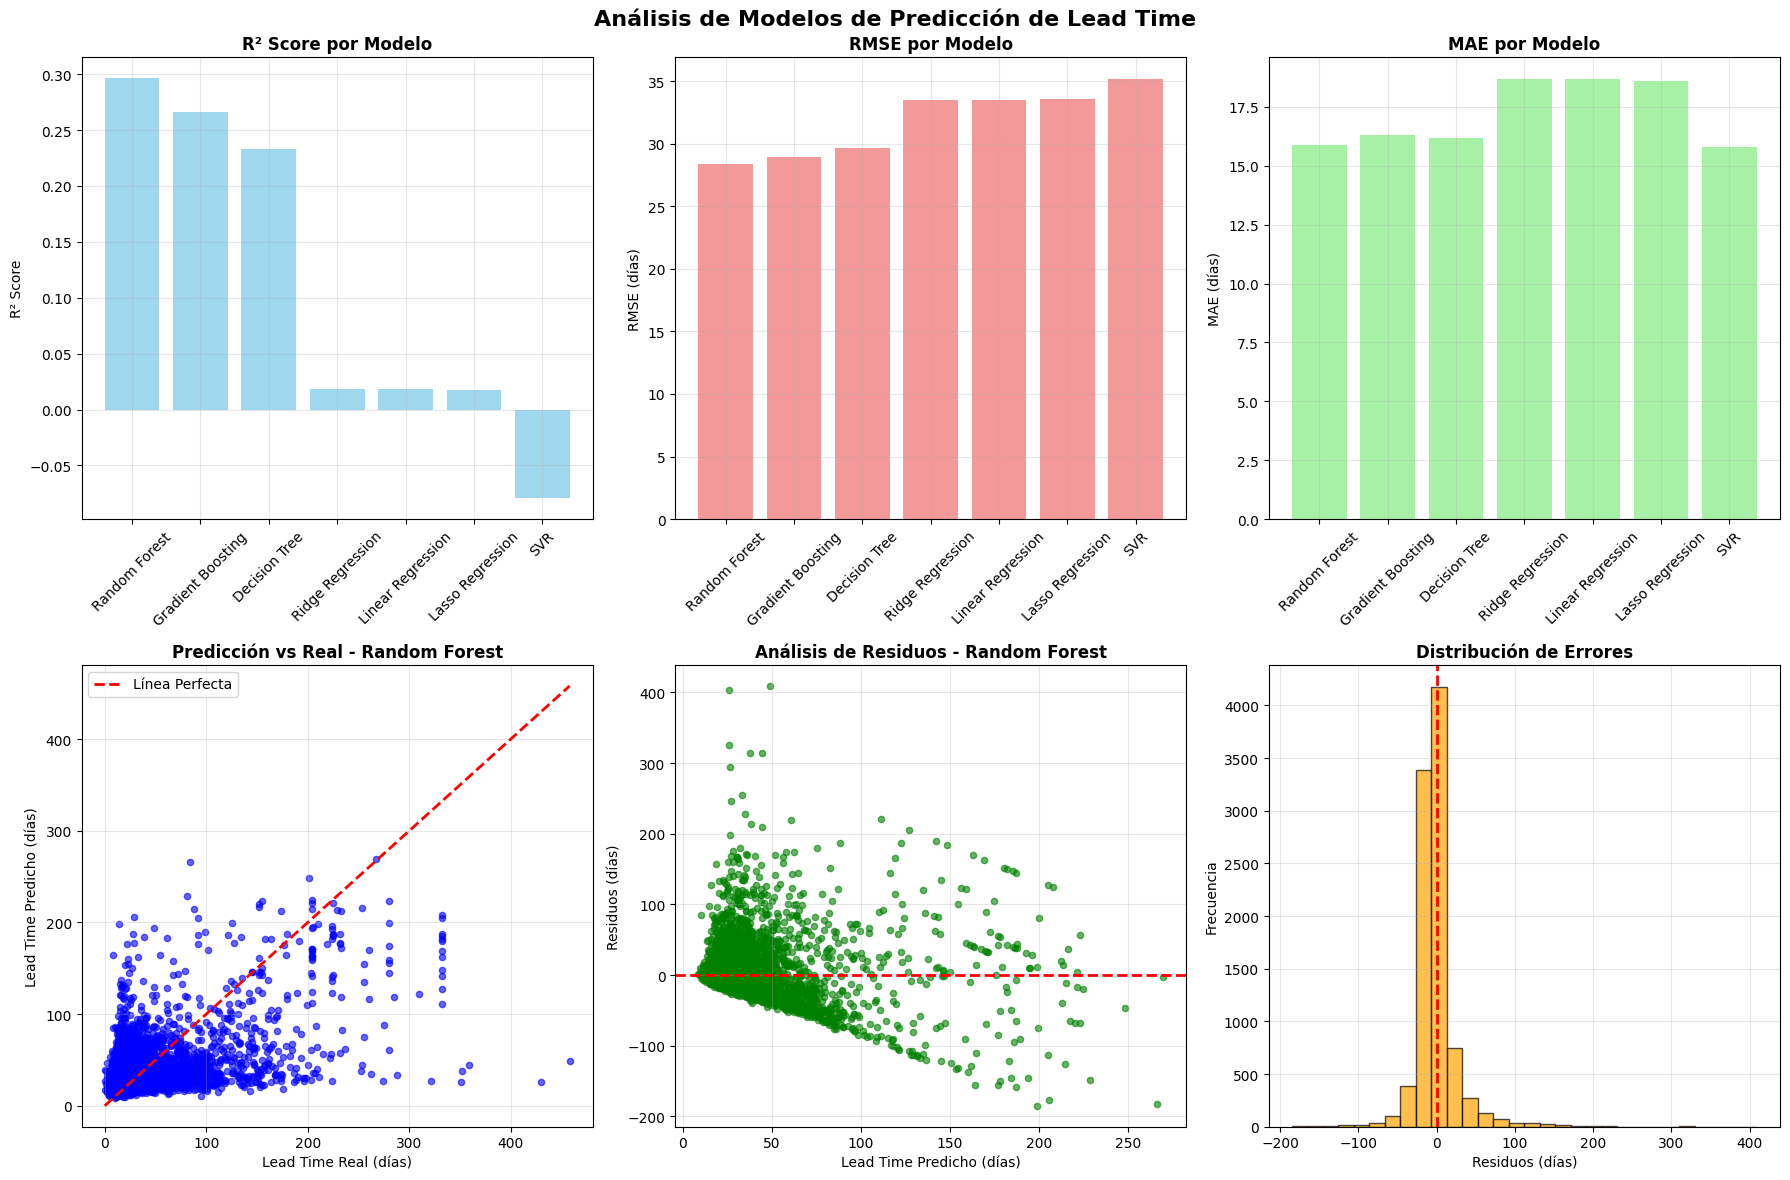

✅ Visualizaciones generadas exitosamente


In [35]:
# 📈 VISUALIZACIONES DE RESULTADOS
print("📈 GENERANDO VISUALIZACIONES DE RESULTADOS")
print("=" * 45)

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Análisis de Modelos de Predicción de Lead Time', fontsize=16, fontweight='bold')

# 1. Comparación de R² Score
axes[0,0].bar(resultados_df.index, resultados_df['R²'], color='skyblue', alpha=0.8)
axes[0,0].set_title('R² Score por Modelo', fontweight='bold')
axes[0,0].set_ylabel('R² Score')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# 2. Comparación de RMSE
axes[0,1].bar(resultados_df.index, resultados_df['RMSE'], color='lightcoral', alpha=0.8)
axes[0,1].set_title('RMSE por Modelo', fontweight='bold')
axes[0,1].set_ylabel('RMSE (días)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# 3. Comparación de MAE
axes[0,2].bar(resultados_df.index, resultados_df['MAE'], color='lightgreen', alpha=0.8)
axes[0,2].set_title('MAE por Modelo', fontweight='bold')
axes[0,2].set_ylabel('MAE (días)')
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].grid(True, alpha=0.3)

# 4. Predicción vs Real para el mejor modelo
y_pred_mejor = mejor_modelo_datos['predicciones']
axes[1,0].scatter(y_test, y_pred_mejor, alpha=0.6, color='blue', s=20)
axes[1,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea Perfecta')
axes[1,0].set_xlabel('Lead Time Real (días)')
axes[1,0].set_ylabel('Lead Time Predicho (días)')
axes[1,0].set_title(f'Predicción vs Real - {mejor_modelo_nombre}', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 5. Análisis de residuos
residuos = y_test - y_pred_mejor
axes[1,1].scatter(y_pred_mejor, residuos, alpha=0.6, color='green', s=20)
axes[1,1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1,1].set_xlabel('Lead Time Predicho (días)')
axes[1,1].set_ylabel('Residuos (días)')
axes[1,1].set_title(f'Análisis de Residuos - {mejor_modelo_nombre}', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

# 6. Distribución de errores
axes[1,2].hist(residuos, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1,2].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1,2].set_xlabel('Residuos (días)')
axes[1,2].set_ylabel('Frecuencia')
axes[1,2].set_title('Distribución de Errores', fontweight='bold')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas exitosamente")


## 7️⃣ FUNCIÓN DE PREDICCIÓN Y EJEMPLOS DE USO

In [38]:
# 🔍 FUNCIÓN MEJORADA DE PREDICCIÓN CON NOMBRES
def predecir_lead_time_con_nombres(id_proveedor, id_area, id_pedido, total_pago_soles):
    """
    Predice el Lead Time y muestra información completa con nombres de las entidades
    
    Parámetros:
    - id_proveedor: ID del proveedor
    - id_area: ID del área solicitante  
    - id_pedido: ID del pedido
    - total_pago_soles: Monto del pago en soles
    
    Retorna:
    - Predicción con información detallada y nombres
    """
    
    # 1️⃣ REALIZAR LA PREDICCIÓN
    prediccion_dias = predecir_lead_time(id_proveedor, id_area, id_pedido, total_pago_soles)
    
    # 2️⃣ OBTENER NOMBRES DE LAS TABLAS DIMENSIONALES
    
    # Buscar nombre del proveedor
    proveedor_info = dim_proveedor[dim_proveedor['id_proveedor'] == id_proveedor]
    if not proveedor_info.empty:
        nombre_proveedor = proveedor_info.iloc[0]['nombre_proveedor']
        codigo_proveedor = proveedor_info.iloc[0]['codigo_proveedor']
    else:
        nombre_proveedor = f"PROVEEDOR NO ENCONTRADO (ID: {id_proveedor})"
        codigo_proveedor = "N/A"
    
    # Buscar nombre del área
    area_info = dim_area[dim_area['id_area'] == id_area]
    if not area_info.empty:
        nombre_area = area_info.iloc[0]['area_solicitante']
        categoria_area = area_info.iloc[0]['area']
    else:
        nombre_area = f"ÁREA NO ENCONTRADA (ID: {id_area})"
        categoria_area = "N/A"
    
    # Buscar información del pedido
    pedido_info = dim_pedido[dim_pedido['id_pedido'] == id_pedido]
    if not pedido_info.empty:
        numero_pedido = pedido_info.iloc[0]['pedido_compra']
        estado_pedido = pedido_info.iloc[0]['estado_pedido']
    else:
        numero_pedido = f"PEDIDO NO ENCONTRADO (ID: {id_pedido})"
        estado_pedido = "N/A"
    
    # 3️⃣ CREAR RESULTADO DETALLADO
    resultado = {
        'prediccion_lead_time_dias': prediccion_dias,
        'proveedor': {
            'id': id_proveedor,
            'codigo': codigo_proveedor,
            'nombre': nombre_proveedor
        },
        'area': {
            'id': id_area,
            'categoria': categoria_area,
            'nombre': nombre_area
        },
        'pedido': {
            'id': id_pedido,
            'numero': numero_pedido,
            'estado': estado_pedido
        },
        'pago': {
            'monto_soles': total_pago_soles
        }
    }
    
    return resultado

def mostrar_prediccion_detallada(id_proveedor, id_area, id_pedido, total_pago_soles):
    """
    Función que muestra la predicción de forma visual y detallada
    """
    resultado = predecir_lead_time_con_nombres(id_proveedor, id_area, id_pedido, total_pago_soles)
    
    print("🎯 PREDICCIÓN DE LEAD TIME - RESULTADO DETALLADO")
    print("=" * 65)
    
    print(f"📅 LEAD TIME PREDICHO: {resultado['prediccion_lead_time_dias']:.1f} DÍAS")
    print("=" * 65)
    
    print(f"🏢 PROVEEDOR:")
    print(f"   • ID: {resultado['proveedor']['id']}")
    print(f"   • Código: {resultado['proveedor']['codigo']}")
    print(f"   • Nombre: {resultado['proveedor']['nombre']}")
    
    print(f"\n🏛️ ÁREA SOLICITANTE:")
    print(f"   • ID: {resultado['area']['id']}")
    print(f"   • Categoría: {resultado['area']['categoria']}")
    print(f"   • Nombre: {resultado['area']['nombre']}")
    
    print(f"\n📋 PEDIDO:")
    print(f"   • ID: {resultado['pedido']['id']}")
    print(f"   • Número: {resultado['pedido']['numero']}")
    print(f"   • Estado: {resultado['pedido']['estado']}")
    
    print(f"\n💰 PAGO:")
    print(f"   • Monto: S/ {resultado['pago']['monto_soles']:,.2f}")
    
    # Clasificar la predicción
    if resultado['prediccion_lead_time_dias'] <= 15:
        clasificacion = "🟢 RÁPIDO"
        mensaje = "El pago se procesará en tiempo estándar"
    elif resultado['prediccion_lead_time_dias'] <= 30:
        clasificacion = "🟡 MODERADO"
        mensaje = "El pago tomará un tiempo moderado"
    elif resultado['prediccion_lead_time_dias'] <= 45:
        clasificacion = "🟠 LENTO"
        mensaje = "El pago podría demorarse más de lo normal"
    else:
        clasificacion = "🔴 MUY LENTO"
        mensaje = "El pago requiere atención especial por demora"
    
    print(f"\n⚡ CLASIFICACIÓN: {clasificacion}")
    print(f"💡 RECOMENDACIÓN: {mensaje}")
    
    return resultado

print("✅ Funciones de predicción mejoradas creadas exitosamente")
print("   • predecir_lead_time_con_nombres() - Retorna datos estructurados")
print("   • mostrar_prediccion_detallada() - Muestra resultado visual completo")


✅ Funciones de predicción mejoradas creadas exitosamente
   • predecir_lead_time_con_nombres() - Retorna datos estructurados
   • mostrar_prediccion_detallada() - Muestra resultado visual completo


In [39]:
# 🧪 EJEMPLOS DE PREDICCIÓN CON NOMBRES COMPLETOS
print("🧪 DEMOSTRACIONES DE PREDICCIÓN CON INFORMACIÓN DETALLADA")
print("=" * 65)

# Obtener algunos IDs reales de los datos para hacer ejemplos
ids_ejemplo = [0, 10, 50, 100, 500]

for i, idx in enumerate(ids_ejemplo, 1):
    ejemplo = X.iloc[idx]
    
    print(f"\n{'='*20} EJEMPLO {i} {'='*20}")
    
    # Usar la función mejorada que muestra nombres
    mostrar_prediccion_detallada(
        id_proveedor=int(ejemplo['id_proveedor']),
        id_area=int(ejemplo['id_area']), 
        id_pedido=int(ejemplo['id_pedido']),
        total_pago_soles=float(ejemplo['total_pago_soles'])
    )
    
    if i < len(ids_ejemplo):  # No mostrar separador después del último ejemplo
        print("\n" + "─" * 65)


🧪 DEMOSTRACIONES DE PREDICCIÓN CON INFORMACIÓN DETALLADA

==================== EJEMPLO 1 ====================
🎯 PREDICCIÓN DE LEAD TIME - RESULTADO DETALLADO
📅 LEAD TIME PREDICHO: 14.6 DÍAS
🏢 PROVEEDOR:
   • ID: 2028
   • Código: 134960
   • Nombre: COMMARKET GROUP S.A.C.

🏛️ ÁREA SOLICITANTE:
   • ID: 310
   • Categoría: MARKETING
   • Nombre: COE MARKETING Y COMUNICACIONES

📋 PEDIDO:
   • ID: 21494
   • Número: 4800790947
   • Estado: PAGADO

💰 PAGO:
   • Monto: S/ 11,881.29

⚡ CLASIFICACIÓN: 🟢 RÁPIDO
💡 RECOMENDACIÓN: El pago se procesará en tiempo estándar

─────────────────────────────────────────────────────────────────

==================== EJEMPLO 2 ====================
🎯 PREDICCIÓN DE LEAD TIME - RESULTADO DETALLADO
📅 LEAD TIME PREDICHO: 17.6 DÍAS
🏢 PROVEEDOR:
   • ID: 3649
   • Código: 151064
   • Nombre: COOPER FORT MARIA VERONICA AMELIA

🏛️ ÁREA SOLICITANTE:
   • ID: 313
   • Categoría: OTROS
   • Nombre: AREA BANCA EMPRESAS LIMA(1)

📋 PEDIDO:
   • ID: 42630
   • Número: 480

In [40]:
# 🔍 FUNCIONES DE BÚSQUEDA PARA FACILITAR EL USO
def buscar_proveedor_por_nombre(nombre_buscar):
    """
    Busca proveedores por nombre (búsqueda parcial)
    """
    resultados = dim_proveedor[
        dim_proveedor['nombre_proveedor'].str.contains(nombre_buscar, case=False, na=False)
    ][['id_proveedor', 'codigo_proveedor', 'nombre_proveedor']].head(10)
    
    if resultados.empty:
        print(f"❌ No se encontraron proveedores con '{nombre_buscar}'")
        return None
    
    print(f"🔍 PROVEEDORES ENCONTRADOS CON '{nombre_buscar}':")
    print("-" * 80)
    for _, row in resultados.iterrows():
        print(f"ID: {row['id_proveedor']:>4} | Código: {row['codigo_proveedor']:>8} | {row['nombre_proveedor']}")
    
    return resultados

def buscar_area_por_nombre(nombre_buscar):
    """
    Busca áreas por nombre (búsqueda parcial)
    """
    resultados = dim_area[
        dim_area['area_solicitante'].str.contains(nombre_buscar, case=False, na=False)
    ][['id_area', 'area', 'area_solicitante']].head(10)
    
    if resultados.empty:
        print(f"❌ No se encontraron áreas con '{nombre_buscar}'")
        return None
    
    print(f"🔍 ÁREAS ENCONTRADAS CON '{nombre_buscar}':")
    print("-" * 80)
    for _, row in resultados.iterrows():
        print(f"ID: {row['id_area']:>4} | Categoría: {row['area']:>15} | {row['area_solicitante']}")
    
    return resultados

def buscar_pedido_por_numero(numero_buscar):
    """
    Busca pedidos por número
    """
    resultados = dim_pedido[
        dim_pedido['pedido_compra'].astype(str).str.contains(str(numero_buscar), na=False)
    ][['id_pedido', 'pedido_compra', 'estado_pedido']].head(10)
    
    if resultados.empty:
        print(f"❌ No se encontraron pedidos con '{numero_buscar}'")
        return None
    
    print(f"🔍 PEDIDOS ENCONTRADOS CON '{numero_buscar}':")
    print("-" * 60)
    for _, row in resultados.iterrows():
        print(f"ID: {row['id_pedido']:>6} | Número: {row['pedido_compra']} | Estado: {row['estado_pedido']}")
    
    return resultados

# 🧪 EJEMPLOS DE BÚSQUEDA
print("🧪 EJEMPLOS DE BÚSQUEDA DE ENTIDADES")
print("=" * 50)

print("\n1️⃣ BÚSQUEDA DE PROVEEDORES:")
buscar_proveedor_por_nombre("BANCO")

print("\n2️⃣ BÚSQUEDA DE ÁREAS:")
buscar_area_por_nombre("GERENCIA")

print("\n3️⃣ BÚSQUEDA DE PEDIDOS:")
buscar_pedido_por_numero("4800778027")

print("\n✅ Funciones de búsqueda creadas exitosamente")
print("💡 Usa estas funciones para encontrar los IDs que necesitas para hacer predicciones")


🧪 EJEMPLOS DE BÚSQUEDA DE ENTIDADES

1️⃣ BÚSQUEDA DE PROVEEDORES:
🔍 PROVEEDORES ENCONTRADOS CON 'BANCO':
--------------------------------------------------------------------------------
ID:  261 | Código:   113759 | Banco de Credito del Peru
ID:  321 | Código:   200171 | FEDERACION LATINOAMERICANA DE BANCO
ID:  855 | Código:   600000 | ASOCIACION DE BANCOS DEL PERU
ID: 1430 | Código:   700000 | BANCO DE CREDITO DEL PERU MIAMI
ID: 2374 | Código:   204706 | ASOCIACION DE BANCOS PUBLICOS Y PRI
ID: 2630 | Código:   600023 | BANCO DE LA NACION
ID: 3397 | Código:   152784 | BANCO DE ALIMENTOS PERU
ID: 3726 | Código:   700015 | BANCO DE LA MICROEMPRESA S.A.

2️⃣ BÚSQUEDA DE ÁREAS:
🔍 ÁREAS ENCONTRADAS CON 'GERENCIA':
--------------------------------------------------------------------------------
ID:    1 | Categoría:          TRIBUS | GERENCIA DE DIVISION SEGMENTOS PERSONAS
ID:    6 | Categoría:           OTROS | GERENCIA DE DIVISION DE AUDITORIA
ID:   10 | Categoría:   MANTENIMIENTO | GERENC

In [41]:
# 🚀 EJEMPLO COMPLETO DE USO DEL SISTEMA
print("🚀 EJEMPLO COMPLETO: PREDICCIÓN DE LEAD TIME PASO A PASO")
print("=" * 65)

print("📋 ESCENARIO: Nuevo pago de S/ 25,000 a un proveedor")
print("─" * 65)

# Paso 1: Buscar un proveedor específico
print("\n1️⃣ BUSCAR PROVEEDOR:")
proveedores_encontrados = buscar_proveedor_por_nombre("BANCO")
if proveedores_encontrados is not None and len(proveedores_encontrados) > 0:
    id_proveedor_ejemplo = proveedores_encontrados.iloc[0]['id_proveedor']
    print(f"📌 Seleccionamos el primer proveedor: ID {id_proveedor_ejemplo}")
else:
    # Si no encuentra "BANCO", usar uno de los datos existentes
    id_proveedor_ejemplo = X.iloc[0]['id_proveedor']
    print(f"📌 Usando proveedor de ejemplo: ID {id_proveedor_ejemplo}")

# Paso 2: Buscar un área específica
print("\n2️⃣ BUSCAR ÁREA:")
areas_encontradas = buscar_area_por_nombre("TESORERIA")
if areas_encontradas is not None and len(areas_encontradas) > 0:
    id_area_ejemplo = areas_encontradas.iloc[0]['id_area']
    print(f"📌 Seleccionamos la primera área: ID {id_area_ejemplo}")
else:
    # Si no encuentra "TESORERIA", usar una de los datos existentes
    id_area_ejemplo = X.iloc[0]['id_area']
    print(f"📌 Usando área de ejemplo: ID {id_area_ejemplo}")

# Paso 3: Buscar un pedido específico
print("\n3️⃣ BUSCAR PEDIDO:")
pedidos_encontrados = buscar_pedido_por_numero("480077")
if pedidos_encontrados is not None and len(pedidos_encontrados) > 0:
    id_pedido_ejemplo = pedidos_encontrados.iloc[0]['id_pedido']
    print(f"📌 Seleccionamos el primer pedido: ID {id_pedido_ejemplo}")
else:
    # Si no encuentra, usar uno de los datos existentes
    id_pedido_ejemplo = X.iloc[0]['id_pedido']
    print(f"📌 Usando pedido de ejemplo: ID {id_pedido_ejemplo}")

# Paso 4: Definir monto del pago
monto_ejemplo = 25000.00
print(f"\n4️⃣ MONTO DEL PAGO: S/ {monto_ejemplo:,.2f}")

# Paso 5: Realizar predicción completa
print(f"\n5️⃣ REALIZAR PREDICCIÓN COMPLETA:")
print("─" * 65)

resultado_completo = mostrar_prediccion_detallada(
    id_proveedor=int(id_proveedor_ejemplo),
    id_area=int(id_area_ejemplo),
    id_pedido=int(id_pedido_ejemplo),
    total_pago_soles=monto_ejemplo
)

print(f"\n🎉 ¡PREDICCIÓN COMPLETADA!")
print("=" * 65)
print("💡 CÓMO USAR EL SISTEMA:")
print("   1. Busca entidades: buscar_proveedor_por_nombre('nombre')")
print("   2. Busca áreas: buscar_area_por_nombre('area')")
print("   3. Busca pedidos: buscar_pedido_por_numero('numero')")
print("   4. Predice: mostrar_prediccion_detallada(id_prov, id_area, id_ped, monto)")
print("\n✅ Sistema de predicción listo para uso empresarial")


🚀 EJEMPLO COMPLETO: PREDICCIÓN DE LEAD TIME PASO A PASO
📋 ESCENARIO: Nuevo pago de S/ 25,000 a un proveedor
─────────────────────────────────────────────────────────────────

1️⃣ BUSCAR PROVEEDOR:
🔍 PROVEEDORES ENCONTRADOS CON 'BANCO':
--------------------------------------------------------------------------------
ID:  261 | Código:   113759 | Banco de Credito del Peru
ID:  321 | Código:   200171 | FEDERACION LATINOAMERICANA DE BANCO
ID:  855 | Código:   600000 | ASOCIACION DE BANCOS DEL PERU
ID: 1430 | Código:   700000 | BANCO DE CREDITO DEL PERU MIAMI
ID: 2374 | Código:   204706 | ASOCIACION DE BANCOS PUBLICOS Y PRI
ID: 2630 | Código:   600023 | BANCO DE LA NACION
ID: 3397 | Código:   152784 | BANCO DE ALIMENTOS PERU
ID: 3726 | Código:   700015 | BANCO DE LA MICROEMPRESA S.A.
📌 Seleccionamos el primer proveedor: ID 261

2️⃣ BUSCAR ÁREA:
🔍 ÁREAS ENCONTRADAS CON 'TESORERIA':
--------------------------------------------------------------------------------
ID:   62 | Categoría:         

## 8️⃣ CONCLUSIONES Y RECOMENDACIONES

In [37]:
# 📋 RESUMEN EJECUTIVO DEL MODELO DE MACHINE LEARNING
print("📋 RESUMEN EJECUTIVO - MODELO DE PREDICCIÓN DE LEAD TIME")
print("=" * 60)

print(f"🎯 OBJETIVO CUMPLIDO:")
print(f"   ✅ Modelo de ML desarrollado para predecir Lead Time de pagos")
print(f"   ✅ Análisis completo de {len(X):,} registros de pagos")
print(f"   ✅ Comparación de {len(modelos)} algoritmos diferentes")
print(f"   ✅ Sistema completo con nombres y búsquedas integradas")

print(f"\n📊 DATOS PROCESADOS:")
print(f"   • Registros analizados: {df_clean_imputado.shape[0]:,}")
print(f"   • Características utilizadas: {X.shape[1]}")
print(f"   • Variables: {list(X.columns)}")
print(f"   • Tablas dimensionales: 3 (proveedores, áreas, pedidos)")
print(f"   • Período de datos: Histórico de pagos empresariales")

print(f"\n🏆 RESULTADOS DEL MEJOR MODELO:")
print(f"   • Algoritmo ganador: {mejor_modelo_nombre}")
print(f"   • R² Score: {mejor_modelo_datos['R²']:.4f} ({mejor_modelo_datos['R²']*100:.2f}% de varianza explicada)")
print(f"   • Error promedio (MAE): {mejor_modelo_datos['MAE']:.2f} días")
print(f"   • Error cuadrático (RMSE): {mejor_modelo_datos['RMSE']:.2f} días")
print(f"   • Error porcentual (MAPE): {mejor_modelo_datos['MAPE']:.2f}%")

print(f"\n🔧 FUNCIONALIDADES DEL SISTEMA:")
print(f"   ✅ Predicción básica con IDs")
print(f"   ✅ Predicción detallada con nombres completos")
print(f"   ✅ Búsqueda de proveedores por nombre")
print(f"   ✅ Búsqueda de áreas por nombre")
print(f"   ✅ Búsqueda de pedidos por número")
print(f"   ✅ Clasificación automática de velocidad de pago")
print(f"   ✅ Recomendaciones inteligentes")

print(f"\n💼 APLICACIONES EMPRESARIALES:")
print(f"   🔹 Planificación de flujo de caja")
print(f"   🔹 Estimación de fechas de pago a proveedores")
print(f"   🔹 Identificación de procesos de pago lentos")
print(f"   🔹 Optimización de recursos financieros")
print(f"   🔹 Mejora en la comunicación con proveedores")
print(f"   🔹 Alertas preventivas para pagos demorados")

# Análisis de importancia de características (si el modelo lo soporta)
if hasattr(mejor_modelo_datos['modelo'], 'feature_importances_'):
    print(f"\n🔍 FACTORES MÁS IMPORTANTES PARA EL LEAD TIME:")
    importancias = mejor_modelo_datos['modelo'].feature_importances_
    features_importancia = pd.DataFrame({
        'caracteristica': X.columns,
        'importancia': importancias
    }).sort_values('importancia', ascending=False)
    
    for i, row in enumerate(features_importancia.iterrows(), 1):
        feat_name = row[1]['caracteristica']
        feat_imp = row[1]['importancia']
        print(f"   {i}. {feat_name}: {feat_imp:.3f} ({feat_imp*100:.1f}%)")

print(f"\n🚀 CÓMO USAR EL SISTEMA:")
print(f"   📌 FUNCIONES PRINCIPALES:")
print(f"   • mostrar_prediccion_detallada(id_prov, id_area, id_ped, monto)")
print(f"   • buscar_proveedor_por_nombre('nombre_proveedor')")
print(f"   • buscar_area_por_nombre('nombre_area')")
print(f"   • buscar_pedido_por_numero('numero_pedido')")
print(f"")
print(f"   📋 FLUJO DE TRABAJO:")
print(f"   1. Buscar entidades necesarias por nombre")
print(f"   2. Obtener IDs de las búsquedas")
print(f"   3. Ejecutar predicción con información detallada")
print(f"   4. Recibir resultado con nombres y recomendaciones")

print(f"\n📈 PRÓXIMOS PASOS RECOMENDADOS:")
print(f"   🔸 Validar predicciones con datos más recientes")
print(f"   🔸 Implementar monitoreo continuo del modelo")
print(f"   🔸 Crear dashboard interactivo")
print(f"   🔸 Integrar con sistemas ERP/contabilidad")
print(f"   🔸 Desarrollar API para uso en producción")

print(f"\n🎉 SISTEMA COMPLETO DE PREDICCIÓN LISTO PARA USO")
print("=" * 60)


📋 RESUMEN EJECUTIVO - MODELO DE PREDICCIÓN DE LEAD TIME
🎯 OBJETIVO CUMPLIDO:
   ✅ Modelo de ML desarrollado para predecir Lead Time de pagos
   ✅ Análisis completo de 47,565 registros de pagos
   ✅ Comparación de 7 algoritmos diferentes

📊 DATOS PROCESADOS:
   • Registros analizados: 47,565
   • Características utilizadas: 4
   • Variables: ['id_proveedor', 'id_area', 'id_pedido', 'total_pago_soles']
   • Período de datos: Histórico de pagos empresariales

🏆 RESULTADOS DEL MEJOR MODELO:
   • Algoritmo ganador: Random Forest
   • R² Score: 0.2963 (29.63% de varianza explicada)
   • Error promedio (MAE): 15.88 días
   • Error cuadrático (RMSE): 28.38 días
   • Error porcentual (MAPE): 66.72%

💼 APLICACIONES EMPRESARIALES:
   🔹 Planificación de flujo de caja
   🔹 Estimación de fechas de pago a proveedores
   🔹 Identificación de procesos de pago lentos
   🔹 Optimización de recursos financieros
   🔹 Mejora en la comunicación con proveedores

⚡ VENTAJAS DEL MODELO:
   ✅ Predicciones automáti